[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/information_theory/04_kl_divergence_and_f_divergences/first_principles.ipynb)

# Module 04 — KL Divergence and f-Divergences

## 1. Why This Module Exists

Two probabilistic descriptions of the same world disagree. A model says the next token is
likely; the data says it is rare. How much does that disagreement cost?

"Cost" has to mean something operational, or the question is empty. Three separate accounting
systems answer it, and they all return the same number.

The **coding** answer: compressing $P$-data with a code built for $Q$ wastes
$D_{\mathrm{KL}}(P \parallel Q)$ nats per symbol. The **testing** answer: the error of the best
test separating $P$ from $Q$ on $n$ samples decays like $e^{-n D_{\mathrm{KL}}(P \parallel Q)}$.
The **learning** answer: maximum likelihood is exactly the minimization of
$D_{\mathrm{KL}}(\hat{P}_n \parallel Q_\theta)$.

That coincidence is what earns relative entropy its place. This module derives it from the
likelihood ratio, then shows it is one member of a family — the $f$-divergences — sharing one
structural theorem: **no processing of the data can increase any of them.**

The second half of the module is about the fact that $D_{\mathrm{KL}}$ is not symmetric. That is
not a defect to be patched; it is a modelling dial whose two settings produce visibly different
fits, and choosing the wrong one is the difference between a blurry model and a confidently
wrong one.

## 2. Intuition

Fix an observation $x$ and ask what it says about the two hypotheses. Bayes' rule multiplies the
prior odds by the **likelihood ratio** $p(x)/q(x)$, so its logarithm is the evidence the
observation contributes, in additive units.

Relative entropy is the average evidence per observation *when $P$ is the one telling the truth*:

$$
D_{\mathrm{KL}}(P \parallel Q) = \mathbb{E}_{X \sim P}\left[\ln\frac{p(X)}{q(X)}\right].
$$

Read that way, three properties are forced. A true hypothesis accumulates evidence in its own
favour, so the average is nonnegative. Running the experiment the other way round is a different
experiment, so the quantity is asymmetric. And degrading $x$ before looking at it cannot sharpen
the comparison, so the quantity can only shrink under processing.

The asymmetry has a picture. **Forward** KL, $D_{\mathrm{KL}}(p \parallel q)$, integrates against
$p$: wherever $p$ has mass and $q$ has none the integrand blows up, so the fitted $q$ must cover
every mode. **Reverse** KL, $D_{\mathrm{KL}}(q \parallel p)$, integrates against $q$: it never
looks at regions $q$ ignores, so the fitted $q$ may sit on one mode and forget the rest.

The figure below fits a single Gaussian to a two-mode target in both directions. It is the whole
module in one picture.

The first code cell is the notebook preamble. It fixes the plotting defaults, seeds the single
random generator used everywhere below, prints the machine epsilon that later residual claims are
measured against, and defines the handful of divergence helpers the rest of the notebook reuses.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from scipy import integrate, special, stats

EPS = np.finfo(float).eps
print(f"machine epsilon = {EPS:.4e}")


def kl(p, q):
    """D_KL(P || Q) in nats, with the conventions 0 ln(0/q) = 0 and p ln(p/0) = +inf."""
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    live = p > 0.0
    if np.any(q[live] == 0.0):
        return np.inf
    return float(np.sum(p[live] * np.log(p[live] / q[live])))


def tv(p, q):
    """Total variation distance, half the L1 distance."""
    return 0.5 * float(np.abs(np.asarray(p, float) - np.asarray(q, float)).sum())


def chi2(p, q):
    """Pearson chi-squared divergence."""
    p = np.asarray(p, float)
    q = np.asarray(q, float)
    return float(np.sum((p - q) ** 2 / q))


def hellinger2(p, q):
    """Squared Hellinger divergence, in [0, 2]."""
    p = np.asarray(p, float)
    q = np.asarray(q, float)
    return float(np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))


def js(p, q):
    """Jensen-Shannon divergence in nats, bounded by ln 2."""
    p = np.asarray(p, float)
    q = np.asarray(q, float)
    m = 0.5 * (p + q)
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)


def f_divergence(p, q, f):
    """D_f(P || Q) = sum_x q(x) f(p(x)/q(x)), for q with full support."""
    p = np.asarray(p, float)
    q = np.asarray(q, float)
    return float(np.sum(q * f(p / q)))

machine epsilon = 2.2204e-16


Every residual reported later is quoted as a multiple of this number.

The next cell draws the picture described above. The target is the two-mode density

$$
p(x) = \tfrac{1}{2}\mathcal{N}(x; -4, 1) + \tfrac{1}{2}\mathcal{N}(x; 4, 1),
$$

and the two fits are the forward-KL optimum $\mathcal{N}(0, 17)$ and the reverse-KL optima
$\mathcal{N}(\pm 4, 1)$. The panel on the right shows the reverse-KL objective as a function of
the fitted mean, so the two symmetric minima and the barrier between them are visible.

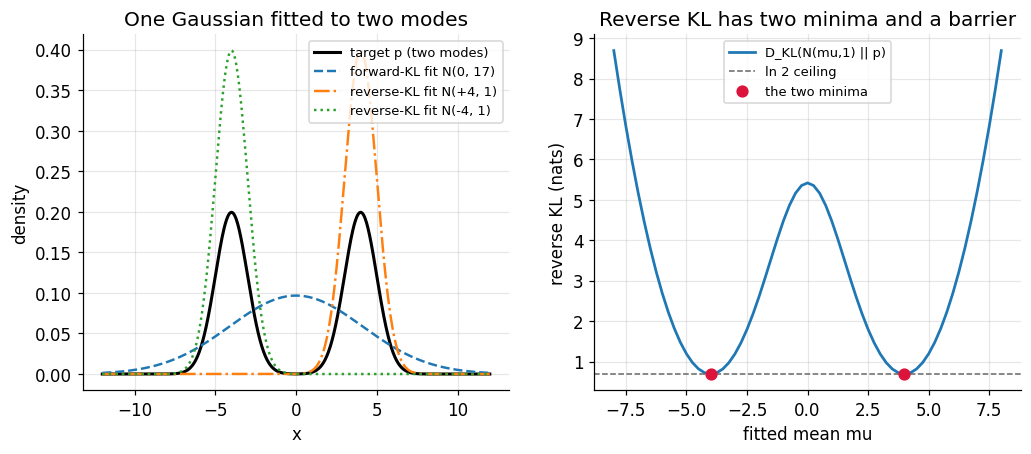

forward-KL optimum          : N(0, 17)
D_KL(N(+4,1) || p)          = 0.693054 nats
D_KL(N(0, 17) || p)         = 2.097617 nats
D_KL(N(0, 1)  || p)         = 5.420989 nats  (the barrier)
ln 2                        = 0.693147 nats


In [2]:
c = 4.0


def log_p_mix(x, c=4.0):
    """log of the two-component target density, computed stably."""
    return np.logaddexp(stats.norm.logpdf(x, -c, 1.0) + np.log(0.5),
                        stats.norm.logpdf(x, c, 1.0) + np.log(0.5))


def reverse_kl_gauss(mu, sigma, c=4.0):
    """D_KL( N(mu, sigma^2) || p ) by quadrature."""
    g = lambda x: stats.norm.pdf(x, mu, sigma) * (
        stats.norm.logpdf(x, mu, sigma) - log_p_mix(x, c))
    return integrate.quad(g, mu - 12 * sigma, mu + 12 * sigma, limit=500)[0]


xs = np.linspace(-12.0, 12.0, 900)
p_x = np.exp(log_p_mix(xs, c))
fwd = stats.norm.pdf(xs, 0.0, np.sqrt(1.0 + c ** 2))
rev_r = stats.norm.pdf(xs, c, 1.0)
rev_l = stats.norm.pdf(xs, -c, 1.0)

mus = np.linspace(-8.0, 8.0, 65)
obj = np.array([reverse_kl_gauss(m, 1.0, c) for m in mus])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.0, 4.2))
ax1.plot(xs, p_x, lw=2.0, color="k", label="target p (two modes)")
ax1.plot(xs, fwd, lw=1.6, ls="--", label="forward-KL fit N(0, 17)")
ax1.plot(xs, rev_r, lw=1.6, ls="-.", label="reverse-KL fit N(+4, 1)")
ax1.plot(xs, rev_l, lw=1.6, ls=":", label="reverse-KL fit N(-4, 1)")
ax1.set_xlabel("x")
ax1.set_ylabel("density")
ax1.set_title("One Gaussian fitted to two modes")
ax1.legend(fontsize=8.5)

ax2.plot(mus, obj, lw=1.8, label="D_KL(N(mu,1) || p)")
ax2.axhline(np.log(2.0), lw=1.0, ls="--", color="0.4", label="ln 2 ceiling")
ax2.plot([-c, c], [reverse_kl_gauss(-c, 1.0, c), reverse_kl_gauss(c, 1.0, c)], "o",
         ms=7, color="crimson", label="the two minima")
ax2.set_xlabel("fitted mean mu")
ax2.set_ylabel("reverse KL (nats)")
ax2.set_title("Reverse KL has two minima and a barrier")
ax2.legend(fontsize=8.5)
plt.show()

print(f"forward-KL optimum          : N(0, {1 + c ** 2:.0f})")
print(f"D_KL(N(+4,1) || p)          = {reverse_kl_gauss(c, 1.0, c):.6f} nats")
print(f"D_KL(N(0, 17) || p)         = {reverse_kl_gauss(0.0, np.sqrt(1 + c ** 2), c):.6f} nats")
print(f"D_KL(N(0, 1)  || p)         = {reverse_kl_gauss(0.0, 1.0, c):.6f} nats  (the barrier)")
print(f"ln 2                        = {np.log(2.0):.6f} nats")

The dashed curve covers both modes and pays for it by putting most of its mass in the empty
valley. The dash-dotted curve fits one mode almost exactly and simply ignores the other.

The right panel shows why the choice is not a matter of taste: the reverse-KL objective has two
separate minima, each sitting just under $\ln 2 = 0.693147$ nats, separated by a barrier that
rises to $5.420989$ nats at $\mu = 0$. A gradient method started on one side never crosses to the
other. Theorem 4.8 turns that picture into an inequality.

## 3. Definitions

Throughout, $\mathcal{X}$ is a finite or countable alphabet and $P, Q$ are probability
distributions on it with mass functions $p, q$. Logarithms are natural unless a result is
explicitly quoted in bits, in which case the conversion is $1 \text{ nat} = 1/\ln 2$ bits.

Symbols follow [the notation register](../../docs/notation.md): $D_{\mathrm{KL}}(P \parallel Q)$
with `\parallel`, $H(X)$ for entropy, $H_{\times}(p, q)$ for cross-entropy, and $H(X, Y)$ reserved
for joint entropy.

### Definition 3.1 — Absolute continuity

$P$ is **absolutely continuous** with respect to $Q$, written $P \ll Q$, when
$q(x) = 0$ implies $p(x) = 0$ for every $x \in \mathcal{X}$.

The condition is one-directional: $P \ll Q$ says nothing about $Q \ll P$. It is the exact
hypothesis under which the ratio $p/q$ is defined $P$-almost everywhere.

### Definition 3.2 — Relative entropy (KL divergence)

For distributions $P, Q$ on $\mathcal{X}$,

$$
D_{\mathrm{KL}}(P \parallel Q) = \sum_{x \in \mathcal{X}} p(x) \ln \frac{p(x)}{q(x)},
$$

with the conventions $0 \ln \tfrac{0}{q} = 0$ and $p \ln \tfrac{p}{0} = +\infty$ for $p \gt 0$.
For densities the sum is replaced by an integral against Lebesgue measure.

So $D_{\mathrm{KL}}(P \parallel Q) \lt \infty$ requires $P \ll Q$, and the quantity is
$+\infty$ otherwise.

### Definition 3.3 — Generator and $f$-divergence

A **generator** is a convex function $f : (0, \infty) \to \mathbb{R}$ with $f(1) = 0$. The
associated **$f$-divergence** is

$$
D_f(P \parallel Q) = \sum_{x \in \mathcal{X}} q(x)\, f\!\left(\frac{p(x)}{q(x)}\right).
$$

For $q(x) = 0$ the term is read as $p(x) f'(\infty)$ with
$f'(\infty) = \lim_{t \to \infty} f(t)/t \in (-\infty, +\infty]$; when $Q$ has full support the
convention never fires. Unless stated otherwise, $Q$ is assumed to have full support below.

$f$ is **strictly convex at $1$** when $f(t) \gt f(1) + c\,(t - 1)$ for every $t \neq 1$ and every
subgradient $c \in \partial f(1)$. This is weaker than strict convexity everywhere and is exactly
what separates divergences that vanish only at $P = Q$ from those that do not.

### Definition 3.4 — The standard members of the family

Each row is a generator and the divergence it produces.

| Divergence | Generator $f(t)$ | Range | Symmetric |
|---|---|---|---|
| Kullback-Leibler | $t \ln t$ | $[0, \infty]$ | no |
| Reverse KL | $-\ln t$ | $[0, \infty]$ | no |
| Total variation | $\tfrac{1}{2}\lvert t - 1 \rvert$ | $[0, 1]$ | yes |
| Pearson $\chi^2$ | $(t-1)^2$ | $[0, \infty]$ | no |
| Squared Hellinger | $(\sqrt{t} - 1)^2$ | $[0, 2]$ | yes |
| Jensen-Shannon | $\tfrac{1}{2}\left[t \ln t - (t+1)\ln\tfrac{t+1}{2}\right]$ | $[0, \ln 2]$ | yes |

Explicitly, $\mathrm{TV}(P,Q) = \tfrac{1}{2}\sum_x \lvert p(x) - q(x) \rvert$,
$\chi^2(P \parallel Q) = \sum_x \frac{(p(x)-q(x))^2}{q(x)}$ and
$H^2(P, Q) = \sum_x \left(\sqrt{p(x)} - \sqrt{q(x)}\right)^2$.

> **Normalization callout.** The Jensen-Shannon row carries a factor $\tfrac{1}{2}$ that is often
> dropped. Without it the generator produces $2\,\mathrm{JS}$, whose ceiling is $2\ln 2$, not
> $\ln 2$. Proposition 4.10 and the code of Example 6.9 pin the factor down.

### Definition 3.5 — Jensen-Shannon divergence

With the mixture $M = \tfrac{1}{2}(P + Q)$,

$$
\mathrm{JS}(P, Q) = \tfrac{1}{2} D_{\mathrm{KL}}(P \parallel M) + \tfrac{1}{2} D_{\mathrm{KL}}(Q \parallel M).
$$

Because $M$ dominates both arguments, $\mathrm{JS}$ is finite for every pair, symmetric by
construction, and bounded by $\ln 2$.

### Definition 3.6 — Channel and induced distributions

A **channel** (Markov kernel) from $\mathcal{X}$ to $\mathcal{Y}$ is a family
$K(y \mid x) \ge 0$ with $\sum_{y} K(y \mid x) = 1$ for every $x$.

It pushes distributions forward:

$$
(KP)(y) = \sum_{x} K(y \mid x)\, p(x), \qquad (KQ)(y) = \sum_{x} K(y \mid x)\, q(x).
$$

Deterministic functions, quantizers, subsampling and additive noise are all channels; the
definition covers them uniformly.

### Definition 3.7 — Sufficiency for a pair of hypotheses

Let $Y$ be the output of a channel $K$ applied to $X$. The output is **sufficient for the pair**
$\{P, Q\}$ when the input likelihood ratio is recoverable from the output, that is

$$
\frac{p(X)}{q(X)} = \frac{(KP)(Y)}{(KQ)(Y)} \qquad \text{almost surely under } Q .
$$

Equivalently, the ratio $p/q$ is constant on every fibre $\{x : K(y \mid x) \gt 0\}$. Nothing
relevant to telling $P$ from $Q$ has been thrown away.

### Definition 3.8 — Empirical distribution and types

For $x^n = (x_1, \ldots, x_n) \in \mathcal{X}^n$ the **empirical distribution** (or **type**) is

$$
\hat{P}_{x^n}(a) = \frac{1}{n}\,\#\{ i : x_i = a \}, \qquad a \in \mathcal{X}.
$$

$\mathcal{P}_n$ denotes the set of types of length $n$, and the **type class** of
$P \in \mathcal{P}_n$ is $T(P) = \{ x^n : \hat{P}_{x^n} = P \}$.

## 4. Main Results

Theorem 4.1 is the entry point: every $f$-divergence is nonnegative and, for the right class of
generators, vanishes only when the two distributions agree.

Theorems 4.2 to 4.4 build the structural core. The log-sum inequality is the elementary tool, joint
convexity is the general statement behind it, and the data-processing inequality — the theorem the
family exists for — falls out of the same convexity argument.

Theorems 4.5 to 4.7 make $D_{\mathrm{KL}}$ computable and comparable: how it decomposes, its closed
form on Gaussians, and how it controls total variation. Theorem 4.8 makes the forward-versus-reverse
asymmetry quantitative, and Theorem 4.9 connects $D_{\mathrm{KL}}$ to the exponent of a large
deviation. Proposition 4.10 records which generators are the same generator.

### Theorem 4.1 — Nonnegativity, and when equality holds

Let $f$ be a generator (Definition 3.3) and let $P, Q$ be distributions on $\mathcal{X}$ with $Q$ of
full support. Then

$$
D_f(P \parallel Q) \ge 0 .
$$

If in addition $f$ is strictly convex at $1$, then $D_f(P \parallel Q) = 0$ if and only if $P = Q$.
In particular $D_{\mathrm{KL}}(P \parallel Q) \ge 0$, with equality exactly at $P = Q$
(**Gibbs' inequality**).

**Hypotheses.** Convexity of $f$ is what makes Jensen point the right way; for a concave $f$ the
inequality reverses, so the sign is not an accident of the formula. $f(1) = 0$ is a normalization:
it is what makes the value at $P = Q$ equal to zero rather than to some constant. Strict convexity
at $1$ is needed only for the equality claim — Section 7 runs the generator
$f(t) = \max(0, t-2)$, which is convex, satisfies $f(1) = 0$, and gives $D_f = 0$ for a pair with
$P \neq Q$.

Proved as Proof 5.1.

### Theorem 4.2 — Log-sum inequality

Let $a_1, \ldots, a_m \ge 0$ and $b_1, \ldots, b_m \gt 0$. Then

$$
\sum_{i=1}^{m} a_i \ln \frac{a_i}{b_i} \; \ge \; \left(\sum_{i=1}^{m} a_i\right) \ln \frac{\sum_{i=1}^{m} a_i}{\sum_{i=1}^{m} b_i},
$$

with the convention $0 \ln 0 = 0$, and with equality if and only if $a_i / b_i$ is the same for
every $i$.

**Hypotheses.** Positivity of the $b_i$ keeps every ratio defined; the $a_i$ may vanish. Nothing
is assumed about normalization, which is what makes the inequality usable on unnormalized blocks
of a distribution.

**Interpretation.** Merging two cells of a distribution can only lose relative entropy, and loses
none exactly when the two cells had the same likelihood ratio. This is the data-processing
inequality in its smallest instance.

Proved as Proof 5.2.

### Theorem 4.3 — Joint convexity of every $f$-divergence

Let $f$ be a generator. Then $(u, v) \mapsto v f(u/v)$ is jointly convex on
$\{u \gt 0, v \gt 0\}$, and consequently, for distributions $P_1, P_2, Q_1, Q_2$ and
$\lambda \in [0, 1]$,

$$
D_f\bigl(\lambda P_1 + (1-\lambda) P_2 \parallel \lambda Q_1 + (1-\lambda) Q_2\bigr)
\; \le \; \lambda D_f(P_1 \parallel Q_1) + (1-\lambda) D_f(P_2 \parallel Q_2).
$$

**Hypotheses.** Convexity of $f$ alone. Note that convexity is *joint*: $D_f$ is not merely convex
in each argument with the other frozen, and the joint statement is the one the proof of
Theorem 4.4 needs.

Proved as Proof 5.3.

### Theorem 4.4 — Data-processing inequality, with its equality case

Let $f$ be a generator, $K$ a channel from $\mathcal{X}$ to $\mathcal{Y}$ (Definition 3.6), and
$P, Q$ distributions on $\mathcal{X}$ with $Q$ of full support. Then

$$
D_f(KP \parallel KQ) \; \le \; D_f(P \parallel Q).
$$

If $f$ is **strictly convex** on $(0, \infty)$, equality holds if and only if the channel output is
sufficient for the pair $\{P, Q\}$ in the sense of Definition 3.7.

**Hypotheses.** Convexity of $f$ gives the inequality; no assumption on $K$ beyond being a channel
is used, so the result covers deterministic maps, quantizers and noise alike. **Strict** convexity
is required for the equality claim and cannot be dropped: total variation has the convex but
piecewise-linear generator $\tfrac{1}{2}\lvert t - 1 \rvert$, and Section 7 exhibits a channel that
preserves $\mathrm{TV}$ exactly while destroying information — $D_{\mathrm{KL}}$ strictly drops
across the same channel.

**Interpretation.** No amount of post-processing, randomized or not, can make two hypotheses easier
to tell apart. Every lower bound in statistics that starts "no estimator can do better than" is an
application of this line.

Proved as Proof 5.4.

### Theorem 4.5 — Chain rule and additivity of relative entropy

Let $P_{XY}$ and $Q_{XY}$ be joint distributions on $\mathcal{X} \times \mathcal{Y}$. Then

$$
D_{\mathrm{KL}}(P_{XY} \parallel Q_{XY}) = D_{\mathrm{KL}}(P_X \parallel Q_X)
+ \mathbb{E}_{x \sim P_X}\left[ D_{\mathrm{KL}}(P_{Y \mid X = x} \parallel Q_{Y \mid X = x}) \right].
$$

In particular, for product measures

$$
D_{\mathrm{KL}}(P^{\otimes n} \parallel Q^{\otimes n}) = n\, D_{\mathrm{KL}}(P \parallel Q).
$$

**Hypotheses.** None beyond $P_{XY} \ll Q_{XY}$, which is what keeps both sides finite. The
conditional term is an average of divergences, hence nonnegative by Theorem 4.1, so the joint
divergence is never smaller than the marginal one.

**Interpretation.** Evidence is additive across a factorization, so $n$ independent observations
carry $n$ times the divergence. That linear growth is what turns into an exponential decay of error
probability in Theorem 4.9.

Proved as Proof 5.5.

### Theorem 4.6 — Relative entropy between Gaussians

For $P = \mathcal{N}(\mu_1, \sigma_1^2)$ and $Q = \mathcal{N}(\mu_2, \sigma_2^2)$ with
$\sigma_1, \sigma_2 \gt 0$,

$$
D_{\mathrm{KL}}(P \parallel Q) = \ln\frac{\sigma_2}{\sigma_1}
+ \frac{\sigma_1^2 + (\mu_1 - \mu_2)^2}{2\sigma_2^2} - \frac{1}{2}.
$$

In $d$ dimensions, for $P = \mathcal{N}(\mu_1, \Sigma_1)$ and $Q = \mathcal{N}(\mu_2, \Sigma_2)$
with $\Sigma_2 \succ 0$,

$$
D_{\mathrm{KL}}(P \parallel Q) = \frac{1}{2}\left[ \operatorname{tr}(\Sigma_2^{-1}\Sigma_1)
+ (\mu_2 - \mu_1)^{\top}\Sigma_2^{-1}(\mu_2 - \mu_1) - d + \ln\frac{\det \Sigma_2}{\det \Sigma_1} \right].
$$

**Hypotheses.** Both variances strictly positive. A degenerate $Q$ has a lower-dimensional support,
so $P \not\ll Q$ and the divergence is $+\infty$ — the continuous version of the zero-cell blow-up
of Definition 3.2.

Proved as Proof 5.6.

### Theorem 4.7 — Pinsker's inequality

For any distributions $P, Q$ on $\mathcal{X}$,

$$
\mathrm{TV}(P, Q) \; \le \; \sqrt{\tfrac{1}{2} D_{\mathrm{KL}}(P \parallel Q)} \qquad \text{(nats)}.
$$

**Hypotheses.** None. The bound is vacuous rather than false when $D_{\mathrm{KL}} = +\infty$.

**No converse exists.** No inequality of the form $D_{\mathrm{KL}} \le C \cdot \mathrm{TV}$ can
hold for a universal constant $C$: a single outcome that $Q$ forbids and $P$ allows with
probability $\varepsilon$ has $\mathrm{TV} = \varepsilon$ and $D_{\mathrm{KL}} = +\infty$.
Section 7 runs the case.

**Interpretation.** Small relative entropy certifies that *no* event separates the two
distributions by much, so no test — however clever — has advantage beyond
$\sqrt{D_{\mathrm{KL}}/2}$ on a single sample.

Proved as Proof 5.7.

### Theorem 4.8 — Forward and reverse KL fit different things

Let $p = \tfrac{1}{2}\mathcal{N}(-c, 1) + \tfrac{1}{2}\mathcal{N}(c, 1)$ with $c \gt 0$, and let
the fitting family be $\mathcal{Q} = \{\mathcal{N}(\mu, \sigma^2) : \sigma \gt 0\}$.

**(a) Forward KL matches moments.** The unique minimizer of
$q \mapsto D_{\mathrm{KL}}(p \parallel q)$ over $\mathcal{Q}$ is
$q^{\star} = \mathcal{N}\bigl(\mathbb{E}_p[X], \operatorname{Var}_p(X)\bigr) = \mathcal{N}(0, 1 + c^2)$.

**(b) Reverse KL prefers one mode.** For every $c \gt 0$,

$$
D_{\mathrm{KL}}\bigl(\mathcal{N}(c, 1) \parallel p\bigr) \; \le \; \ln 2,
\qquad
D_{\mathrm{KL}}\bigl(\mathcal{N}(0, 1 + c^2) \parallel p\bigr)
\; \ge \; \frac{1}{2}\left[ 2c^2 - 2c\sqrt{\frac{2(1+c^2)}{\pi}} - \ln(1 + c^2) \right],
$$

and the right-hand bound grows without bound in $c$. So beyond a finite $c$ the single-mode fit
strictly beats the moment-matched fit in reverse KL, while part (a) says the moment-matched fit is
the unique forward-KL optimum.

**Hypotheses.** Only $c \gt 0$ and the Gaussian family. The mechanism is general: forward KL
integrates against $p$ and is therefore infinite wherever $q$ starves a region $p$ occupies;
reverse KL integrates against $q$ and never inspects a region $q$ vacates.

Proved as Proof 5.8.

### Theorem 4.9 — Sanov's upper bound (method of types)

Let $\mathcal{X}$ be finite, let $Q$ have full support on $\mathcal{X}$, let $X_1, \ldots, X_n$ be
i.i.d. $Q$, and let $\hat{P}_n$ be their empirical distribution (Definition 3.8). For any set $E$
of distributions on $\mathcal{X}$, writing
$D^{\star} = \inf_{P \in E} D_{\mathrm{KL}}(P \parallel Q)$,

$$
\mathbb{P}\bigl(\hat{P}_n \in E\bigr) \; \le \; (n+1)^{\lvert \mathcal{X} \rvert}\, e^{-n D^{\star}},
\qquad\text{hence}\qquad
\limsup_{n \to \infty} \frac{1}{n} \ln \mathbb{P}\bigl(\hat{P}_n \in E\bigr) \le -D^{\star}.
$$

**Hypotheses.** Finiteness of $\mathcal{X}$ is what makes the type count polynomial in $n$, and
therefore subexponential; full support of $Q$ keeps $D_{\mathrm{KL}}(P \parallel Q)$ finite for
every $P$ in the simplex.

**Matching lower bound (cited, not proved here).** If $E$ is the closure of its interior, the limit
exists and equals $-D^{\star}$; see Cover and Thomas, *Elements of Information Theory*, 2nd ed.,
Theorem 11.4.1, p. 362. The minimizing $P^{\star}$ is the $I$-projection of $Q$ onto $E$, and for
convex $E$ it is unique.

**Interpretation.** A rare empirical distribution is exponentially rare at rate exactly its
relative entropy from the truth, and the cheapest way to see an unlikely sample is the one closest
to $Q$ in $D_{\mathrm{KL}}$.

Proved as Proof 5.9.

### Proposition 4.10 — When two generators give the same divergence

Let $f$ be a generator, $a \in \mathbb{R}$ and $\kappa \gt 0$. Then
$g(t) = \kappa f(t) + a\,(t-1)$ is also a generator, and for all $P, Q$

$$
D_g(P \parallel Q) = \kappa \, D_f(P \parallel Q).
$$

In particular the affine term is invisible ($\kappa = 1$), and the scale is not: the generator
$t\ln t - (t+1)\ln\tfrac{t+1}{2}$ produces $2\,\mathrm{JS}$, whose ceiling is $2 \ln 2$, whereas the
generator of Definition 3.4 produces $\mathrm{JS}$ itself.

**Interpretation.** Generators are only defined up to $c(t-1)$ and up to a positive scale, so a
table of generators is meaningless unless the normalization is stated. Choosing $a = -f'(1)$ makes
$f$ nonnegative and is the normalization used by the estimator $k_3$ of the exercises.

Proved as Proof 5.10.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, nonnegativity and equality)

The argument is the supporting-hyperplane form of Jensen, which delivers the inequality and its
equality case in one pass.

**Step 1 — normalize the generator.** $f$ is convex and finite on $(0, \infty)$, so it has a
subgradient $c$ at $t = 1$. Put

$$
\tilde{f}(t) = f(t) - c\,(t - 1).
$$

Then $\tilde{f}$ is convex, $\tilde{f}(1) = f(1) = 0$, and by the subgradient inequality
$\tilde{f}(t) \ge 0$ for every $t \gt 0$.

**Step 2 — the affine part contributes nothing.** Because $P$ and $Q$ are both normalized,

$$
\sum_x q(x)\, c\left(\frac{p(x)}{q(x)} - 1\right) = c\left(\sum_x p(x) - \sum_x q(x)\right) = 0,
$$

so $D_f(P \parallel Q) = D_{\tilde{f}}(P \parallel Q)$.

**Step 3 — conclude.** Every summand of $D_{\tilde{f}}(P \parallel Q) = \sum_x q(x)\tilde{f}(p(x)/q(x))$
is a nonnegative number times a nonnegative weight, hence

$$
D_f(P \parallel Q) = \sum_x q(x)\, \tilde{f}\!\left(\frac{p(x)}{q(x)}\right) \ge 0 .
$$

**Step 4 — equality.** Suppose $f$ is strictly convex at $1$, so $\tilde{f}(t) \gt 0$ for every
$t \neq 1$. The sum in Step 3 vanishes only if $\tilde{f}(p(x)/q(x)) = 0$ for every $x$ with
$q(x) \gt 0$, that is $p(x) = q(x)$ on the support of $Q$. Since $Q$ has full support this is
$P = Q$; conversely $P = Q$ gives $\tilde{f}(1) = 0$ termwise.

$$
\boxed{D_f(P \parallel Q) \ge 0, \qquad \text{and } D_f = 0 \iff P = Q \text{ when } f \text{ is strictly convex at } 1}
$$

**Interpretation.** Nonnegativity is not a property of the logarithm; it is a property of
convexity plus normalization, which is why the entire family inherits it at once. For
$f(t) = t \ln t$ this is Gibbs' inequality, and the same three lines therefore make Modules 01 and
02 self-contained: the tangent-line bound $\ln t \le t - 1$ is Step 1 with $c = f'(1)$.
$\blacksquare$

### Proof 5.2 (of Theorem 4.2, log-sum inequality)

Set $b = \sum_i b_i \gt 0$ and $\lambda_i = b_i / b$, so the $\lambda_i$ are nonnegative and sum to
one.

**Step 1.** The function $g(t) = t \ln t$ is convex on $(0, \infty)$, with $g''(t) = 1/t \gt 0$,
and extends continuously to $g(0) = 0$.

**Step 2.** Apply Jensen with the weights $\lambda_i$ at the points $t_i = a_i / b_i$:

$$
\sum_i \lambda_i\, g\!\left(\frac{a_i}{b_i}\right) \;\ge\; g\!\left(\sum_i \lambda_i \frac{a_i}{b_i}\right)
= g\!\left(\frac{\sum_i a_i}{b}\right).
$$

**Step 3.** Multiply both sides by $b$. The left side becomes
$\sum_i b_i \frac{a_i}{b_i}\ln\frac{a_i}{b_i} = \sum_i a_i \ln\frac{a_i}{b_i}$, and the right side
becomes $\left(\sum_i a_i\right)\ln\frac{\sum_i a_i}{\sum_i b_i}$.

$$
\boxed{\sum_{i} a_i \ln \frac{a_i}{b_i} \; \ge \; \left(\sum_{i} a_i\right) \ln \frac{\sum_{i} a_i}{\sum_{i} b_i}}
$$

**Step 4 — equality.** $g$ is strictly convex, so Jensen is tight only when $a_i/b_i$ takes the
same value for every $i$ with $\lambda_i \gt 0$, that is for every $i$.

**Interpretation.** Pooling two cells never increases relative entropy, and costs nothing exactly
when the pooled cells were indistinguishable in likelihood ratio. Applying the inequality to
$a_i = p(x_i)$, $b_i = q(x_i)$ over all of $\mathcal{X}$ recovers Gibbs' inequality, since the
right-hand side is $1 \cdot \ln 1 = 0$. $\blacksquare$

### Proof 5.3 (of Theorem 4.3, joint convexity)

**Step 1 — the perspective inequality.** Let $f$ be convex, let $u_1, \ldots, u_m \gt 0$,
$v_1, \ldots, v_m \gt 0$, and set $\bar{u} = \sum_i u_i$, $\bar{v} = \sum_i v_i$. The weights
$w_i = v_i / \bar{v}$ are nonnegative and sum to one, and

$$
\sum_i w_i \frac{u_i}{v_i} = \frac{\bar{u}}{\bar{v}} .
$$

Jensen for the convex $f$ therefore gives

$$
f\!\left(\frac{\bar{u}}{\bar{v}}\right) \;\le\; \sum_i w_i\, f\!\left(\frac{u_i}{v_i}\right),
$$

and multiplying by $\bar{v}$ yields the **perspective inequality**

$$
\bar{v}\, f\!\left(\frac{\bar{u}}{\bar{v}}\right) \;\le\; \sum_i v_i\, f\!\left(\frac{u_i}{v_i}\right).
$$

**Step 2 — joint convexity of the perspective.** Taking $m = 2$ with $u_i \to \lambda_i u_i$ and
$v_i \to \lambda_i v_i$ for $\lambda_1 = \lambda$, $\lambda_2 = 1 - \lambda$, and using
$\lambda_i v_i f(\lambda_i u_i / (\lambda_i v_i)) = \lambda_i \, v_i f(u_i/v_i)$, Step 1 reads

$$
g\bigl(\lambda u_1 + (1-\lambda)u_2, \; \lambda v_1 + (1-\lambda) v_2\bigr)
\;\le\; \lambda\, g(u_1, v_1) + (1-\lambda)\, g(u_2, v_2)
$$

for $g(u, v) = v f(u/v)$. So $g$ is jointly convex.

**Step 3 — sum over the alphabet.** $D_f(P \parallel Q) = \sum_x g(p(x), q(x))$ is a sum of jointly
convex functions of the pair, hence jointly convex.

$$
\boxed{(u,v) \mapsto v f(u/v) \text{ is jointly convex, hence so is } (P,Q) \mapsto D_f(P \parallel Q)}
$$

**Interpretation.** Mixing two pairs of hypotheses can only make them harder to separate than the
average of separating them individually. Taking $f(t) = t\ln t$ gives joint convexity of
$D_{\mathrm{KL}}$, the claim the module README makes and the reason the data-processing inequality
is a convexity statement rather than a computation. $\blacksquare$

### Proof 5.4 (of Theorem 4.4, the data-processing inequality)

Write $P' = KP$ and $Q' = KQ$, and let $Y$ be the channel output.

**Step 1 — apply the perspective inequality fibre by fibre.** Fix $y$ with $q'(y) \gt 0$ and apply
Step 1 of Proof 5.3 with $u_x = K(y \mid x) p(x)$ and $v_x = K(y \mid x) q(x)$, so that
$\bar{u} = p'(y)$ and $\bar{v} = q'(y)$:

$$
q'(y)\, f\!\left(\frac{p'(y)}{q'(y)}\right)
\;\le\; \sum_{x} K(y \mid x)\, q(x)\, f\!\left(\frac{p(x)}{q(x)}\right),
$$

where the ratio $u_x / v_x = p(x)/q(x)$ does not depend on $y$ — this is the one cancellation the
whole proof turns on.

**Step 2 — sum over the output alphabet.** Every $K(y \mid x)$ is summed over $y$ against the same
$x$-term, and $\sum_y K(y \mid x) = 1$:

$$
D_f(P' \parallel Q') = \sum_y q'(y) f\!\left(\frac{p'(y)}{q'(y)}\right)
\;\le\; \sum_x \left(\sum_y K(y \mid x)\right) q(x) f\!\left(\frac{p(x)}{q(x)}\right)
= D_f(P \parallel Q).
$$

$$
\boxed{D_f(KP \parallel KQ) \;\le\; D_f(P \parallel Q) \text{ for every channel } K}
$$

**Step 3 — the equality case, for strictly convex $f$.** The total slack is the sum over $y$ of the
slack in Step 1. For a strictly convex $f$, Jensen at a fixed $y$ is tight if and only if the
points $p(x)/q(x)$ are equal for all $x$ carrying positive weight $w_x^{(y)} = K(y\mid x)q(x)/q'(y)$,
that is for all $x$ in the fibre $\{x : K(y \mid x) \gt 0\}$ (recall $Q$ has full support).

When that holds for every $y$ with $q'(y) \gt 0$, the common value on the fibre must be the average
$p'(y)/q'(y)$, so $p(X)/q(X) = p'(Y)/q'(Y)$ almost surely under $Q$: the output is sufficient for
$\{P, Q\}$ (Definition 3.7). Conversely, if the output is sufficient the ratio is constant on each
fibre and every Jensen step is an equality.

**Interpretation.** Processing loses nothing exactly when it keeps the likelihood ratio, which is
precisely the classical statement that a sufficient statistic carries all the discriminating
information. The strict-convexity hypothesis is load-bearing: for total variation, whose generator
is affine on each side of $1$, a channel can merge two symbols with different likelihood ratios and
still preserve $\mathrm{TV}$, as Section 7 demonstrates. $\blacksquare$

### Proof 5.5 (of Theorem 4.5, chain rule and additivity)

**Step 1 — factor the log-ratio.** With $p(x,y) = p(x)p(y \mid x)$ and $q(x,y) = q(x)q(y \mid x)$,

$$
\ln \frac{p(x,y)}{q(x,y)} = \ln\frac{p(x)}{q(x)} + \ln\frac{p(y \mid x)}{q(y \mid x)} .
$$

**Step 2 — take the expectation under $P_{XY}$.** The first term depends on $x$ only, and its
expectation is $D_{\mathrm{KL}}(P_X \parallel Q_X)$. For the second, condition on $X$ first:

$$
\mathbb{E}_{P_{XY}}\left[\ln\frac{p(Y \mid X)}{q(Y \mid X)}\right]
= \mathbb{E}_{x \sim P_X}\left[\sum_y p(y \mid x)\ln\frac{p(y \mid x)}{q(y \mid x)}\right]
= \mathbb{E}_{x \sim P_X}\left[D_{\mathrm{KL}}(P_{Y \mid X=x} \parallel Q_{Y \mid X=x})\right].
$$

**Step 3 — specialize to products.** If $P_{XY} = P_1 \otimes P_2$ and $Q_{XY} = Q_1 \otimes Q_2$
the conditionals do not depend on $x$, so the conditional term is the constant
$D_{\mathrm{KL}}(P_2 \parallel Q_2)$ and the chain rule reads
$D_{\mathrm{KL}}(P_1 \parallel Q_1) + D_{\mathrm{KL}}(P_2 \parallel Q_2)$. Induction on the number
of factors gives the $n$-fold statement.

$$
\boxed{D_{\mathrm{KL}}(P_{XY} \parallel Q_{XY}) = D_{\mathrm{KL}}(P_X \parallel Q_X) + \mathbb{E}_{P_X}\left[D_{\mathrm{KL}}(P_{Y \mid X} \parallel Q_{Y \mid X})\right]}
$$

**Interpretation.** Divergence is bookkeeping over a factorization: each conditional contributes
its own nonnegative amount, so a model that gets the marginal right can still be arbitrarily wrong
on the conditionals, and the joint divergence sees it. $\blacksquare$

### Proof 5.6 (of Theorem 4.6, the Gaussian closed form)

**Step 1 — the log-ratio of densities.**

$$
\ln\frac{p(x)}{q(x)} = \ln\frac{\sigma_2}{\sigma_1} - \frac{(x-\mu_1)^2}{2\sigma_1^2} + \frac{(x-\mu_2)^2}{2\sigma_2^2}.
$$

**Step 2 — two moments under $P$.** First, $\mathbb{E}_P\left[(X-\mu_1)^2\right] = \sigma_1^2$, so
the middle term contributes $-\tfrac{1}{2}$.

Second, expanding around $\mu_1$,

$$
(X-\mu_2)^2 = (X-\mu_1)^2 + 2(X-\mu_1)(\mu_1-\mu_2) + (\mu_1-\mu_2)^2 ,
$$

whose middle term has zero mean under $P$, so
$\mathbb{E}_P\left[(X-\mu_2)^2\right] = \sigma_1^2 + (\mu_1-\mu_2)^2$.

**Step 3 — assemble.**

$$
D_{\mathrm{KL}}(P \parallel Q) = \ln\frac{\sigma_2}{\sigma_1} - \frac{1}{2} + \frac{\sigma_1^2 + (\mu_1-\mu_2)^2}{2\sigma_2^2}.
$$

Setting $P = Q$ gives $\ln 1 + \tfrac{\sigma^2}{2\sigma^2} - \tfrac12 = 0$, as Theorem 4.1 demands.

$$
\boxed{D_{\mathrm{KL}}\bigl(\mathcal{N}(\mu_1,\sigma_1^2) \parallel \mathcal{N}(\mu_2,\sigma_2^2)\bigr) = \ln\frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (\mu_1-\mu_2)^2}{2\sigma_2^2} - \frac{1}{2}}
$$

**Step 4 — the multivariate case.** The same computation with
$\mathbb{E}_P\left[(X-\mu_1)(X-\mu_1)^{\top}\right] = \Sigma_1$ and the identity
$\mathbb{E}\left[z^{\top} A z\right] = \operatorname{tr}(A \Sigma) + m^{\top} A m$ for
$z \sim \mathcal{N}(m, \Sigma)$ produces the stated $d$-dimensional formula.

**Interpretation.** The formula separates cleanly into a shape penalty $\ln(\sigma_2/\sigma_1) +
\sigma_1^2/(2\sigma_2^2) - \tfrac12$ and a location penalty $(\mu_1-\mu_2)^2/(2\sigma_2^2)$; the
diagonal-versus-standard-normal case is the regularizer of every Gaussian variational autoencoder.
$\blacksquare$

### Proof 5.7 (of Theorem 4.7, Pinsker's inequality)

**Step 1 — reduce to two points, using Theorem 4.4.** Let $A = \{x : p(x) \ge q(x)\}$ and let $K$
be the deterministic channel $x \mapsto \mathbf{1}\{x \in A\}$. Then

$$
\mathrm{TV}(P, Q) = P(A) - Q(A) = \mathrm{TV}(KP, KQ),
$$

because the positive and negative parts of $p - q$ have equal total mass. Writing $a = P(A)$ and
$b = Q(A)$, the pushforwards are $\mathrm{Ber}(a)$ and $\mathrm{Ber}(b)$, and Theorem 4.4 gives

$$
D_{\mathrm{KL}}(\mathrm{Ber}(a) \parallel \mathrm{Ber}(b)) \le D_{\mathrm{KL}}(P \parallel Q).
$$

It therefore suffices to prove the inequality for Bernoulli pairs.

**Step 2 — the Bernoulli case.** For $a \in (0,1)$ fixed, define on $b \in (0,1)$

$$
g(b) = a \ln\frac{a}{b} + (1-a)\ln\frac{1-a}{1-b} - 2(a-b)^2 .
$$

Differentiating,

$$
g'(b) = -\frac{a}{b} + \frac{1-a}{1-b} + 4(a-b) = \frac{b-a}{b(1-b)} + 4(a-b) = (b-a)\left(\frac{1}{b(1-b)} - 4\right).
$$

Since $b(1-b) \le \tfrac14$ on $(0,1)$, the bracket is nonnegative, so $g'$ has the sign of $b - a$:
$g$ decreases on $(0, a)$ and increases on $(a, 1)$. Hence $g$ attains its minimum at $b = a$, where
$g(a) = 0$, and therefore $g \ge 0$ everywhere:

$$
D_{\mathrm{KL}}(\mathrm{Ber}(a) \parallel \mathrm{Ber}(b)) \ge 2 (a-b)^2 .
$$

The boundary cases $b \in \{0, 1\}$ with $a \neq b$ give $D_{\mathrm{KL}} = +\infty$ and hold
trivially.

**Step 3 — combine.** Chaining Steps 1 and 2 with $\mathrm{TV}(P,Q) = a - b$,

$$
D_{\mathrm{KL}}(P \parallel Q) \;\ge\; 2\,\mathrm{TV}(P,Q)^2 .
$$

$$
\boxed{\mathrm{TV}(P, Q) \le \sqrt{\tfrac{1}{2} D_{\mathrm{KL}}(P \parallel Q)}}
$$

**Interpretation.** The reduction step is the data-processing inequality doing real work: an
inequality about arbitrary alphabets is proved by checking a single two-outcome case. The bound is
tight only in the limit $P \to Q$; Section 7 measures the slack. $\blacksquare$

### Proof 5.8 (of Theorem 4.8, forward versus reverse KL)

Write $\phi$ for the standard normal density and $q_{\mu,\sigma}$ for the density of
$\mathcal{N}(\mu, \sigma^2)$.

**Part (a) — forward KL matches moments.**

$$
D_{\mathrm{KL}}(p \parallel q_{\mu,\sigma}) = \underbrace{\int p \ln p}_{\text{free of } (\mu,\sigma)} - \int p(x) \ln q_{\mu,\sigma}(x)\, dx,
$$

so minimizing is maximizing $\int p \ln q_{\mu,\sigma}$. Writing that integral out,

$$
\int p(x) \ln q_{\mu,\sigma}(x)\,dx = -\tfrac{1}{2}\ln(2\pi\sigma^2) - \frac{\mathbb{E}_p\left[(X-\mu)^2\right]}{2\sigma^2}.
$$

Because $\mathbb{E}_p[(X-\mu)^2] = \operatorname{Var}_p(X) + (\mathbb{E}_p[X] - \mu)^2$, the choice
$\mu = \mathbb{E}_p[X]$ is optimal for every $\sigma$; substituting it and differentiating in
$\sigma^2$ gives $\sigma^2 = \operatorname{Var}_p(X)$, a strict maximum since the objective
$-\tfrac12\ln \sigma^2 - v/(2\sigma^2)$ is strictly concave in $\ln \sigma^2$.

For the two-mode target, $\mathbb{E}_p[X] = 0$ and
$\operatorname{Var}_p(X) = \mathbb{E}_p[X^2] = 1 + c^2$, so $q^{\star} = \mathcal{N}(0, 1+c^2)$.

**Part (b), upper bound.** Since $p(x) \ge \tfrac{1}{2}\phi(x - c)$ pointwise,

$$
D_{\mathrm{KL}}\bigl(\mathcal{N}(c,1) \parallel p\bigr) = \mathbb{E}_{X \sim \mathcal{N}(c,1)}\left[\ln\frac{\phi(X-c)}{p(X)}\right] \le \ln 2 .
$$

**Part (b), lower bound.** For $x \ge 0$ we have $\phi(x-c) \ge \phi(x+c)$, so
$p(x) \le \phi(\lvert x \rvert - c)$, and by symmetry this holds for all $x$. Hence

$$
-\ln p(x) \ge \tfrac{1}{2}\ln(2\pi) + \tfrac{1}{2}\left(\lvert x \rvert - c\right)^2 .
$$

Let $s^2 = 1 + c^2$ and $X \sim \mathcal{N}(0, s^2)$, for which
$\mathbb{E}\lvert X \rvert = s\sqrt{2/\pi}$ and $\mathbb{E}[X^2] = s^2$. Then

$$
\mathbb{E}\left[(\lvert X \rvert - c)^2\right] = s^2 - 2cs\sqrt{\tfrac{2}{\pi}} + c^2 .
$$

The differential entropy of $\mathcal{N}(0,s^2)$ is $\tfrac12\ln(2\pi e s^2)$, so

$$
D_{\mathrm{KL}}\bigl(\mathcal{N}(0,s^2) \parallel p\bigr) = -\tfrac{1}{2}\ln(2\pi e s^2) - \mathbb{E}\left[\ln p(X)\right]
\ge \tfrac{1}{2}\left(s^2 + c^2 - 2cs\sqrt{\tfrac{2}{\pi}} - 1 - \ln s^2\right).
$$

Substituting $s^2 = 1 + c^2$ gives the stated bound

$$
D_{\mathrm{KL}}\bigl(\mathcal{N}(0, 1+c^2) \parallel p\bigr) \ge \tfrac{1}{2}\left(2c^2 - 2c\sqrt{\tfrac{2(1+c^2)}{\pi}} - \ln(1+c^2)\right),
$$

whose leading term is $c^2\bigl(1 - \sqrt{2/\pi}\bigr) \approx 0.2021\,c^2 \to \infty$.

$$
\boxed{\text{forward: } \mathcal{N}(0, 1+c^2) \text{ uniquely}; \qquad \text{reverse: the one-mode fit beats it once } c \text{ is large}}
$$

**Interpretation.** The two objectives disagree not slightly but qualitatively: one is a moment
match, the other a mode selection, and the gap grows quadratically in the mode separation. Maximum
likelihood and distillation optimize the first; variational inference and KL-regularized policy
optimization optimize the second. $\blacksquare$

### Proof 5.9 (of Theorem 4.9, Sanov's upper bound)

Three counting lemmas, then one line.

**Step 1 — there are few types.** A type of length $n$ is determined by the
$\lvert \mathcal{X} \rvert$ counts $n \hat{P}(a) \in \{0, 1, \ldots, n\}$, so

$$
\lvert \mathcal{P}_n \rvert \le (n+1)^{\lvert \mathcal{X} \rvert} .
$$

**Step 2 — the probability of a string depends only on its type.** If $\hat{P}_{x^n} = P$ then

$$
Q^n(x^n) = \prod_{a \in \mathcal{X}} q(a)^{n P(a)} = e^{\,n \sum_a P(a) \ln q(a)} = e^{-n\left(H(P) + D_{\mathrm{KL}}(P \parallel Q)\right)},
$$

using $-\sum_a P(a)\ln q(a) = H(P) + D_{\mathrm{KL}}(P \parallel Q)$.

**Step 3 — a type class is not too large.** Applying Step 2 with $Q$ replaced by $P$ gives
$P^n(x^n) = e^{-nH(P)}$ for every $x^n \in T(P)$, so

$$
1 \;\ge\; P^n\bigl(T(P)\bigr) = \lvert T(P) \rvert \, e^{-nH(P)}
\qquad\Longrightarrow\qquad
\lvert T(P) \rvert \le e^{\,nH(P)} .
$$

**Step 4 — combine.** For a single type $P \in \mathcal{P}_n$, Steps 2 and 3 give

$$
Q^n\bigl(T(P)\bigr) = \lvert T(P)\rvert\, e^{-n(H(P) + D_{\mathrm{KL}}(P \parallel Q))} \le e^{-n D_{\mathrm{KL}}(P \parallel Q)} .
$$

Summing over the types that land in $E$, and bounding each exponent by the best one,

$$
\mathbb{P}\bigl(\hat{P}_n \in E\bigr) = \sum_{P \in E \cap \mathcal{P}_n} Q^n\bigl(T(P)\bigr)
\le \lvert \mathcal{P}_n \rvert \, e^{-n D^{\star}} \le (n+1)^{\lvert \mathcal{X} \rvert} e^{-n D^{\star}} .
$$

$$
\boxed{\mathbb{P}\bigl(\hat{P}_n \in E\bigr) \le (n+1)^{\lvert \mathcal{X} \rvert} e^{-n D^{\star}}, \qquad D^{\star} = \inf_{P \in E} D_{\mathrm{KL}}(P \parallel Q)}
$$

Taking $\tfrac{1}{n}\ln$ of both sides sends the polynomial prefactor to zero and leaves
$\limsup_n \tfrac1n \ln \mathbb{P}(\hat{P}_n \in E) \le -D^{\star}$.

**Interpretation.** The polynomial factor is the entire cost of not knowing which type occurred:
there are only polynomially many candidates, and each is exponentially unlikely at its own KL rate.
The matching lower bound, cited with Theorem 4.9, comes from the fact that a single type class
carries probability $e^{-nD}$ up to the same polynomial factor. $\blacksquare$

### Proof 5.10 (of Proposition 4.10, generator equivalence)

**Step 1 — $g$ is a generator.** $g = \kappa f + a(t-1)$ is convex because $\kappa \gt 0$ and an
affine function is convex, and $g(1) = \kappa f(1) + 0 = 0$.

**Step 2 — the affine part integrates to zero.** As in Step 2 of Proof 5.1,

$$
\sum_x q(x)\, a\left(\frac{p(x)}{q(x)} - 1\right) = a\left(\sum_x p(x) - \sum_x q(x)\right) = 0 .
$$

**Step 3 — the scale does not.** Linearity of the sum gives
$D_g(P \parallel Q) = \kappa\, D_f(P \parallel Q)$.

$$
\boxed{D_{\kappa f + a(t-1)} = \kappa\, D_f \quad \text{for } \kappa \gt 0,\; a \in \mathbb{R}}
$$

**Interpretation.** Two generators define the same divergence exactly when they differ by an affine
term; a different positive scale is a different divergence with the same shape. The Jensen-Shannon
row of Definition 3.4 is the case that matters in practice, and Example 6.6 checks the factor
numerically. $\blacksquare$

## 6. Worked Examples

Every result of Section 4 gets one fully computed example here, on objects small enough to finish
by hand: three-outcome distributions, one two-by-two joint table, one pair of Gaussians, one coin.
Two code cells recompute all of them and assert the stated numbers.

### Example 6.1 — Both directions of a Bernoulli divergence (Theorem 4.1)

Take $P = \mathrm{Ber}(0.9)$ and $Q = \mathrm{Ber}(0.5)$ on $\{1, 0\}$.

*Forward.* Against the uniform $Q$ every log-ratio picks up the same $\ln 2$, so

$$
D_{\mathrm{KL}}(P \parallel Q) = 0.9 \ln \frac{0.9}{0.5} + 0.1 \ln \frac{0.1}{0.5}
= 0.9 \ln 1.8 + 0.1 \ln 0.2 .
$$

With $\ln 1.8 = 0.587787$ and $\ln 0.2 = -1.609438$ this is
$0.529008 - 0.160944 = 0.368064$ nats, i.e. $0.531004$ bits.

*Reverse.* Now the reference is the skewed $P$:

$$
D_{\mathrm{KL}}(Q \parallel P) = \tfrac12 \ln\frac{0.5}{0.9} + \tfrac12 \ln\frac{0.5}{0.1}
= \tfrac12 \ln\frac{25}{9} = 0.510826 \text{ nats} = 0.736966 \text{ bits}.
$$

**Interpretation.** Both are positive, as Theorem 4.1 requires, and they differ by $39$ percent.
Describing a near-deterministic source with a uniform code wastes little; describing a fair coin
with a code that reserves $\log_2 10 \approx 3.32$ bits for one face wastes a lot on the half of
the trials that land there.

### Example 6.2 — Log-sum on two cells, and joint convexity (Theorems 4.2, 4.3)

Take the first two cells of the pair used below: $a = (0.5, 0.3)$ and $b = (0.1, 0.2)$.

*Left side.* $0.5 \ln 5 + 0.3 \ln 1.5 = 0.8047190 + 0.1216395 = 0.9263585$.

*Right side.* $(0.5 + 0.3)\ln\frac{0.5+0.3}{0.1+0.2} = 0.8 \ln \tfrac{8}{3} = 0.8 \times 0.9808293 = 0.7846634$.

*Gap.* $0.9263585 - 0.7846634 = 0.1416951$, strictly positive because the two likelihood ratios
$5$ and $1.5$ differ, exactly as the equality clause of Theorem 4.2 predicts.

*Joint convexity.* Take $P_1 = (0.9, 0.1)$, $P_2 = (0.1, 0.9)$, $Q_1 = Q_2 = (0.5, 0.5)$ and
$\lambda = \tfrac12$. The mixtures are $\bar{P} = \bar{Q} = (0.5, 0.5)$, so the left side of
Theorem 4.3 is $0$, while the right side is
$\tfrac12 (0.368064) + \tfrac12 (0.368064) = 0.368064$.

**Interpretation.** Averaging two perfectly distinguishable situations produced one perfectly
indistinguishable one: mixing destroys divergence, which is convexity read backwards.

### Example 6.3 — A channel that keeps TV and destroys KL (Theorem 4.4)

Let $\mathcal{X} = \{1, 2, 3\}$ with

$$
P = (0.5,\; 0.3,\; 0.2), \qquad Q = (0.1,\; 0.2,\; 0.7),
$$

and let $K$ merge the first two symbols: $K(a \mid 1) = K(a \mid 2) = 1$, $K(b \mid 3) = 1$.

*Before.* $D_{\mathrm{KL}}(P \parallel Q) = 0.5\ln 5 + 0.3 \ln 1.5 + 0.2 \ln \tfrac{2}{7}
= 0.8047190 + 0.1216395 - 0.2505526 = 0.6758059$.

*After.* $KP = (0.8, 0.2)$ and $KQ = (0.3, 0.7)$, so
$D_{\mathrm{KL}}(KP \parallel KQ) = 0.8 \ln \tfrac83 + 0.2 \ln \tfrac27 = 0.7846634 - 0.2505526 = 0.5341108$.

The drop is $0.1416951$ — the same number as the log-sum gap of Example 6.2, because the merged
cells are the only ones the channel touches.

*Total variation.* $p - q = (0.4, 0.1, -0.5)$, so $\mathrm{TV} = 0.5$; after the merge
$KP - KQ = (0.5, -0.5)$ and $\mathrm{TV} = 0.5$ again. The channel is **not** sufficient — the
likelihood ratios $5$ and $1.5$ of the merged symbols disagree — yet total variation is unchanged.

**Interpretation.** Theorem 4.4 gives inequality for both divergences and equality for neither
automatically. $D_{\mathrm{KL}}$ has a strictly convex generator, so it must strictly drop when
sufficiency fails; $\mathrm{TV}$ has a piecewise-linear generator, so it can sit at equality. This
is the counterexample that forces the strict-convexity hypothesis into the equality clause.

### Example 6.4 — The chain rule on a two-by-two table (Theorem 4.5)

Under both $P$ and $Q$ let $X \sim \mathrm{Ber}(1/2)$. Under $P$, $Y \mid X{=}1 \sim \mathrm{Ber}(0.9)$
and $Y \mid X{=}0 \sim \mathrm{Ber}(0.1)$; under $Q$, $Y \mid X \sim \mathrm{Ber}(0.5)$ regardless.

*Joint tables.* On $(x,y) \in \{(1,1), (1,0), (0,1), (0,0)\}$,

$$
P_{XY} = (0.45,\; 0.05,\; 0.05,\; 0.45), \qquad Q_{XY} = (0.25,\; 0.25,\; 0.25,\; 0.25).
$$

*Chain rule.* The marginals agree, so the first term vanishes. Each conditional term is the
Example 6.1 number $0.368064$, and averaging two equal values leaves $0.368064$.

*Direct.* $2(0.45)\ln 1.8 + 2(0.05)\ln 0.2 = 0.529008 - 0.160944 = 0.368064$. The two routes agree.

**Interpretation.** All of the divergence lives in the conditionals; a model with the right
marginal and the wrong dependence structure is caught by the joint divergence and invisible to the
marginal one.

### Example 6.5 — Two Gaussians, both directions (Theorem 4.6)

Take $P = \mathcal{N}(1, 0.5^2)$ and $Q = \mathcal{N}(0, 1^2)$.

$$
D_{\mathrm{KL}}(P \parallel Q) = \ln\frac{1}{0.5} + \frac{0.25 + 1}{2}- \frac12
= 0.693147 + 0.625 - 0.5 = 0.818147 .
$$

$$
D_{\mathrm{KL}}(Q \parallel P) = \ln\frac{0.5}{1} + \frac{1 + 1}{2 (0.25)} - \frac12
= -0.693147 + 4 - 0.5 = 2.806853 .
$$

**Interpretation.** The reverse direction is $3.43$ times larger. Placing a narrow distribution
inside a wide one is cheap; placing a wide one inside a narrow one is expensive, because the wide
distribution keeps sampling the narrow one's tails. This is the same asymmetry as Theorem 4.8, in
its simplest instance.

### Example 6.6 — How much slack does Pinsker leave? (Theorem 4.7)

For the pair of Example 6.1, $\mathrm{TV}(P, Q) = \tfrac12(\lvert 0.9 - 0.5 \rvert + \lvert 0.1 - 0.5 \rvert) = 0.4$
and $D_{\mathrm{KL}}(P \parallel Q) = 0.368064$ nats, so

$$
\sqrt{\tfrac12 D_{\mathrm{KL}}(P \parallel Q)} = \sqrt{0.184032} = 0.428990 .
$$

The bound holds with slack $0.028990$, about $7$ percent.

Contrast the Example 6.3 pair, where $\mathrm{TV} = 0.5$ and $D_{\mathrm{KL}} = 0.675806$: the
bound reads $0.581294 \ge 0.5$, slack $16$ percent.

**Interpretation.** Pinsker is tight only as $P \to Q$; away from that limit it is a genuine but
loose certificate. It is still the right tool, because the quantity one can usually compute
($D_{\mathrm{KL}}$) is the one on the wrong side of the inequality.

### Example 6.7 — Which fit wins in which direction (Theorem 4.8)

Take $c = 4$, so $p = \tfrac12 \mathcal{N}(-4,1) + \tfrac12 \mathcal{N}(4,1)$ with
$\mathbb{E}_p[X] = 0$ and $\operatorname{Var}_p(X) = 17$.

*Forward optimum.* By Theorem 4.8(a) it is $\mathcal{N}(0, 17)$, and the forward divergences are
$D_{\mathrm{KL}}(p \parallel \mathcal{N}(0,17)) = 0.723553$ against
$D_{\mathrm{KL}}(p \parallel \mathcal{N}(4,1)) = 15.306946$: the wide fit wins by a factor of $21$.

*Reverse ranking.* The one-mode fit gives
$D_{\mathrm{KL}}(\mathcal{N}(4,1) \parallel p) = 0.693054$, just under the ceiling
$\ln 2 = 0.693147$ of Theorem 4.8(b). The moment-matched fit gives
$D_{\mathrm{KL}}(\mathcal{N}(0,17) \parallel p) = 2.097617$, above the analytic lower bound

$$
\tfrac12\left(2 \cdot 16 - 2 \cdot 4\sqrt{\tfrac{2 \cdot 17}{\pi}} - \ln 17\right) = 1.424344 .
$$

**Interpretation.** The same two candidates are ranked in opposite orders by the two directions,
and the ranking is not marginal: forward prefers the wide fit twenty-fold, reverse prefers the
narrow fit threefold. There is no direction-free notion of "the best Gaussian approximation".

### Example 6.8 — A fair coin that looks biased (Theorem 4.9)

Let $Q = \mathrm{Ber}(1/2)$ and $E = \{ P : P(\text{heads}) \ge 0.7 \}$. The $I$-projection of $Q$
onto $E$ is the boundary point $P^{\star} = \mathrm{Ber}(0.7)$, and

$$
D^{\star} = 0.7 \ln 1.4 + 0.3 \ln 0.6 = 0.235531 - 0.153248 = 0.082283 \text{ nats}
= 0.118709 \text{ bits}.
$$

Theorem 4.9 therefore predicts
$\mathbb{P}(\hat{P}_n \in E) \le (n+1)^2 e^{-0.082283\, n}$, and an exponent converging to
$0.082283$. The exact binomial tail at $n = 2000$ gives
$-\tfrac1n \ln \mathbb{P} = 0.083974$, within $2$ percent.

**Interpretation.** The rate is the relative entropy of the *closest* distribution in $E$, not of
some typical one, and the closest is the boundary point $0.7$. Seeing $70$ percent heads in $2000$
fair tosses has probability $10^{-73}$, and the exponent that produces that number is a KL
divergence.

### Example 6.9 — The Jensen-Shannon generator, with and without its factor (Proposition 4.10)

For the pair of Example 6.3, the mixture is $M = \tfrac12(P+Q) = (0.3, 0.25, 0.45)$ and

$$
\mathrm{JS}(P, Q) = \tfrac12 D_{\mathrm{KL}}(P \parallel M) + \tfrac12 D_{\mathrm{KL}}(Q \parallel M) = 0.151358 .
$$

Feeding the *unhalved* generator $f(t) = t\ln t - (t+1)\ln\tfrac{t+1}{2}$ into Definition 3.3
returns $0.302716 = 2 \times 0.151358$ — twice the Jensen-Shannon divergence, as Proposition 4.10
says it must.

**Interpretation.** The unhalved generator is the one printed in most $f$-GAN tables, and its
divergence is bounded by $2\ln 2 = 1.386294$, not $\ln 2$. Quoting the $\ln 2$ ceiling next to it
is the arithmetic error this example exists to rule out.

The next cell recomputes Examples 6.1 to 6.4 and asserts every number stated above.

In [3]:
print("Example 6.1 - Bernoulli, both directions")
P_ber = np.array([0.9, 0.1])
Q_ber = np.array([0.5, 0.5])
d_fwd, d_rev = kl(P_ber, Q_ber), kl(Q_ber, P_ber)
print(f"  D(P||Q) = {d_fwd:.6f} nats = {d_fwd / np.log(2):.6f} bits")
print(f"  D(Q||P) = {d_rev:.6f} nats = {d_rev / np.log(2):.6f} bits  = 0.5*ln(25/9) = "
      f"{0.5 * np.log(25 / 9):.6f}")
print(f"  ratio   = {d_rev / d_fwd:.6f}")
assert abs(d_fwd - 0.368064) < 5e-7 and abs(d_rev - 0.5 * np.log(25 / 9)) < 1e-12

print("\nExample 6.2 - log-sum and joint convexity")
a = np.array([0.5, 0.3])
b = np.array([0.1, 0.2])
lhs = float(np.sum(a * np.log(a / b)))
rhs = float(a.sum() * np.log(a.sum() / b.sum()))
print(f"  sum a_i ln(a_i/b_i)          = {lhs:.6f}")
print(f"  (sum a) ln(sum a / sum b)    = {rhs:.6f}")
print(f"  gap                          = {lhs - rhs:.6f}   (ratios a/b = {a / b})")
P1, P2 = np.array([0.9, 0.1]), np.array([0.1, 0.9])
Q1 = Q2 = np.array([0.5, 0.5])
lam = 0.5
mix_l = kl(lam * P1 + (1 - lam) * P2, lam * Q1 + (1 - lam) * Q2)
mix_r = lam * kl(P1, Q1) + (1 - lam) * kl(P2, Q2)
print(f"  D(mix || mix) = {mix_l:.6f}   <=   mixture of divergences = {mix_r:.6f}")
assert lhs > rhs and abs((lhs - rhs) - 0.141695) < 5e-7
assert mix_l <= mix_r + 1e-12

print("\nExample 6.3 - a channel that keeps TV and destroys KL")
P3 = np.array([0.5, 0.3, 0.2])
Q3 = np.array([0.1, 0.2, 0.7])
K = np.array([[1.0, 1.0, 0.0],
              [0.0, 0.0, 1.0]])          # rows indexed by y, columns by x
KP, KQ = K @ P3, K @ Q3
print(f"  likelihood ratios p/q        = {P3 / Q3}")
print(f"  KL  before = {kl(P3, Q3):.6f}   after = {kl(KP, KQ):.6f}   drop = "
      f"{kl(P3, Q3) - kl(KP, KQ):.6f}")
print(f"  TV  before = {tv(P3, Q3):.6f}   after = {tv(KP, KQ):.6f}   drop = "
      f"{tv(P3, Q3) - tv(KP, KQ):.6f}")
print(f"  chi2 before = {chi2(P3, Q3):.6f}  after = {chi2(KP, KQ):.6f}")
print(f"  H^2  before = {hellinger2(P3, Q3):.6f}  after = {hellinger2(KP, KQ):.6f}")
assert abs(kl(P3, Q3) - kl(KP, KQ) - 0.141695) < 5e-7
assert abs(tv(P3, Q3) - tv(KP, KQ)) < 1e-15

print("\nExample 6.4 - chain rule on a 2x2 table")
P_joint = np.array([0.45, 0.05, 0.05, 0.45])
Q_joint = np.full(4, 0.25)
cond_terms = [kl(np.array([0.9, 0.1]), Q_ber), kl(np.array([0.1, 0.9]), Q_ber)]
chain = 0.0 + 0.5 * cond_terms[0] + 0.5 * cond_terms[1]
print(f"  direct     D(P_XY || Q_XY) = {kl(P_joint, Q_joint):.6f} nats")
print(f"  chain rule marginal + E[conditional] = 0 + {chain:.6f} nats")
print(f"  in bits                              = {kl(P_joint, Q_joint) / np.log(2):.6f}")
assert abs(kl(P_joint, Q_joint) - chain) < 1e-12
print("\nall assertions passed")

Example 6.1 - Bernoulli, both directions
  D(P||Q) = 0.368064 nats = 0.531004 bits
  D(Q||P) = 0.510826 nats = 0.736966 bits  = 0.5*ln(25/9) = 0.510826
  ratio   = 1.387871

Example 6.2 - log-sum and joint convexity
  sum a_i ln(a_i/b_i)          = 0.926358
  (sum a) ln(sum a / sum b)    = 0.784663
  gap                          = 0.141695   (ratios a/b = [5.  1.5])
  D(mix || mix) = 0.000000   <=   mixture of divergences = 0.368064

Example 6.3 - a channel that keeps TV and destroys KL
  likelihood ratios p/q        = [5.     1.5    0.2857]
  KL  before = 0.675806   after = 0.534111   drop = 0.141695
  TV  before = 0.500000   after = 0.500000   drop = 0.000000
  chi2 before = 2.007143  after = 1.190476
  H^2  before = 0.314557  after = 0.271873

Example 6.4 - chain rule on a 2x2 table
  direct     D(P_XY || Q_XY) = 0.368064 nats
  chain rule marginal + E[conditional] = 0 + 0.368064 nats
  in bits                              = 0.531004

all assertions passed


Every hand-computed figure is reproduced digit for digit. The two lines worth pausing on are the
Example 6.3 pair: relative entropy falls by $0.141695$ across the merge while total variation does
not move at all, and the log-sum gap of Example 6.2 accounts for the entire drop.

The next cell recomputes Examples 6.5 to 6.9 and asserts those numbers, including the exact
binomial tail behind the Sanov exponent.

In [4]:
def gauss_kl(m1, s1, m2, s2):
    """Closed form of Theorem 4.6 in one dimension."""
    return np.log(s2 / s1) + (s1 ** 2 + (m1 - m2) ** 2) / (2 * s2 ** 2) - 0.5


print("Example 6.5 - two Gaussians")
print(f"  D(N(1,0.5^2) || N(0,1)) = {gauss_kl(1, 0.5, 0, 1):.6f}")
print(f"  D(N(0,1) || N(1,0.5^2)) = {gauss_kl(0, 1, 1, 0.5):.6f}")
print(f"  ratio                   = {gauss_kl(0, 1, 1, 0.5) / gauss_kl(1, 0.5, 0, 1):.6f}")
assert abs(gauss_kl(1, 0.5, 0, 1) - 0.818147) < 5e-7

print("\nExample 6.6 - Pinsker slack")
for name, (Pa, Qa) in {"Ber(0.9) vs Ber(0.5)": (P_ber, Q_ber),
                       "Example 6.3 pair": (P3, Q3)}.items():
    bound = np.sqrt(0.5 * kl(Pa, Qa))
    print(f"  {name:22s}  TV = {tv(Pa, Qa):.6f}  <=  sqrt(KL/2) = {bound:.6f}"
          f"   slack = {bound - tv(Pa, Qa):.6f}")
    assert tv(Pa, Qa) <= bound

print("\nExample 6.7 - forward and reverse rank the same two fits differently")
def forward_kl_gauss(mu, sigma, c=4.0):
    g = lambda x: np.exp(log_p_mix(x, c)) * (log_p_mix(x, c) - stats.norm.logpdf(x, mu, sigma))
    return integrate.quad(g, -40.0, 40.0, limit=500)[0]


s_star = np.sqrt(1.0 + c ** 2)
print(f"  forward : D(p || N(0,17)) = {forward_kl_gauss(0.0, s_star):.6f}"
      f"   D(p || N(4,1)) = {forward_kl_gauss(c, 1.0):.6f}")
print(f"  reverse : D(N(4,1) || p)  = {reverse_kl_gauss(c, 1.0):.6f}"
      f"   D(N(0,17) || p) = {reverse_kl_gauss(0.0, s_star):.6f}")
lower = 0.5 * (2 * c ** 2 - 2 * c * np.sqrt(2 * (1 + c ** 2) / np.pi) - np.log(1 + c ** 2))
print(f"  ceiling ln 2 = {np.log(2.0):.6f}   analytic lower bound = {lower:.6f}")
assert reverse_kl_gauss(c, 1.0) <= np.log(2.0)
assert reverse_kl_gauss(0.0, s_star) >= lower
assert forward_kl_gauss(0.0, s_star) < forward_kl_gauss(c, 1.0)

print("\nExample 6.8 - Sanov exponent for a fair coin")
D_star = kl(np.array([0.7, 0.3]), np.array([0.5, 0.5]))
print(f"  D* = D(Ber(0.7) || Ber(0.5)) = {D_star:.6f} nats = {D_star / np.log(2):.6f} bits")
print("      n     exact tail      -ln(tail)/n    type-count bound exponent")
for n in (200, 500, 2000, 5000):
    log_tail = float(np.log(stats.binom.sf(int(np.ceil(0.7 * n)) - 1, n, 0.5)))
    bound_exp = D_star - 2 * np.log(n + 1) / n
    print(f"  {n:6d}   {np.exp(log_tail):.6e}    {-log_tail / n:.6f}       {bound_exp:.6f}")
    assert -log_tail / n >= bound_exp

print("\nExample 6.9 - the Jensen-Shannon generator and its factor of two")
M3 = 0.5 * (P3 + Q3)
js_val = js(P3, Q3)
f_unhalved = lambda t: t * np.log(t) - (t + 1) * np.log((t + 1) / 2)
d_unhalved = f_divergence(P3, Q3, f_unhalved)
d_halved = f_divergence(P3, Q3, lambda t: 0.5 * f_unhalved(t))
print(f"  M = {M3}")
print(f"  JS(P,Q) from Definition 3.5      = {js_val:.6f}")
print(f"  D_f with the unhalved generator  = {d_unhalved:.6f}  = {d_unhalved / js_val:.6f} x JS")
print(f"  D_f with the halved generator    = {d_halved:.6f}")
print(f"  ceilings: ln 2 = {np.log(2.0):.6f},  2 ln 2 = {2 * np.log(2.0):.6f}")
assert abs(d_halved - js_val) < 1e-12
assert abs(d_unhalved - 2 * js_val) < 1e-12
print("\nall assertions passed")

Example 6.5 - two Gaussians
  D(N(1,0.5^2) || N(0,1)) = 0.818147
  D(N(0,1) || N(1,0.5^2)) = 2.806853
  ratio                   = 3.430743

Example 6.6 - Pinsker slack
  Ber(0.9) vs Ber(0.5)    TV = 0.400000  <=  sqrt(KL/2) = 0.428990   slack = 0.028990
  Example 6.3 pair        TV = 0.500000  <=  sqrt(KL/2) = 0.581294   slack = 0.081294

Example 6.7 - forward and reverse rank the same two fits differently


  forward : D(p || N(0,17)) = 0.723553   D(p || N(4,1)) = 15.306946


  reverse : D(N(4,1) || p)  = 0.693054   D(N(0,17) || p) = 2.097617
  ceiling ln 2 = 0.693147   analytic lower bound = 1.424344



Example 6.8 - Sanov exponent for a fair coin
  D* = D(Ber(0.7) || Ber(0.5)) = 0.082283 nats = 0.118709 bits
      n     exact tail      -ln(tail)/n    type-count bound exponent
     200   7.535308e-09    0.093518       0.029250
     500   9.171233e-20    0.087671       0.057416
    2000   1.151987e-73    0.083974       0.074681
    5000   4.549893e-181    0.083051       0.078876

Example 6.9 - the Jensen-Shannon generator and its factor of two
  M = [0.3  0.25 0.45]
  JS(P,Q) from Definition 3.5      = 0.151358
  D_f with the unhalved generator  = 0.302716  = 2.000000 x JS
  D_f with the halved generator    = 0.151358
  ceilings: ln 2 = 0.693147,  2 ln 2 = 1.386294

all assertions passed


The Gaussian closed form, the Pinsker slack, the two-way ranking of the mixture fits and the
Sanov exponent all reproduce the hand computations.

The last block settles Definition 3.4: the halved generator returns exactly
$\mathrm{JS} = 0.151358$ and the unhalved one returns exactly twice that. Only the halved version
is compatible with the $\ln 2$ ceiling.

## 7. Computational Practice

Seven experiments. The first checks an identity to machine precision, the second measures the
order of an approximation, the third breaks three hypotheses on purpose, the fourth puts the
hand-written code against SciPy, and the last three draw the pictures the theorems describe.

### 7.1 Residuals of the boxed identities

The first cell checks three exact statements on concrete numbers and prints each residual as a
multiple of machine epsilon: the cross-entropy decomposition
$H_{\times}(p, q) = H(p) + D_{\mathrm{KL}}(p \parallel q)$, the chain rule of Theorem 4.5 on ten
random joint tables, and the Gaussian closed form of Theorem 4.6 against numerical quadrature.

In [5]:
p_leg = np.array([0.7, 0.2, 0.1])
q_leg = np.array([0.4, 0.4, 0.2])
H_p = float(-np.sum(p_leg * np.log(p_leg)))
H_cross = float(-np.sum(p_leg * np.log(q_leg)))
r_decomp = abs(H_cross - (H_p + kl(p_leg, q_leg)))
print("cross-entropy decomposition  H_x(p,q) = H(p) + D_KL(p||q)")
print(f"  H(p)      = {H_p:.10f}")
print(f"  H_x(p,q)  = {H_cross:.10f}")
print(f"  D_KL      = {kl(p_leg, q_leg):.10f}")
print(f"  residual  = {r_decomp:.3e}  = {r_decomp / EPS:5.2f} * eps")
assert r_decomp < 10 * EPS

print("\nchain rule of Theorem 4.5, ten random 3 x 4 joint tables")
worst = 0.0
for _ in range(10):
    Pxy = rng.dirichlet(np.ones(12)).reshape(3, 4)
    Qxy = rng.dirichlet(np.ones(12)).reshape(3, 4)
    Px, Qx = Pxy.sum(axis=1), Qxy.sum(axis=1)
    cond = sum(Px[i] * kl(Pxy[i] / Px[i], Qxy[i] / Qx[i]) for i in range(3))
    worst = max(worst, abs(kl(Pxy.ravel(), Qxy.ravel()) - (kl(Px, Qx) + cond)))
print(f"  worst |joint - (marginal + conditional)| = {worst:.3e}  = {worst / EPS:5.2f} * eps")
assert worst < 50 * EPS

print("\nGaussian closed form of Theorem 4.6 against quadrature")
for (m1, s1, m2, s2) in [(1.0, 0.5, 0.0, 1.0), (0.0, 1.0, 1.0, 0.5), (-2.0, 1.5, 0.5, 0.8)]:
    g = lambda x: stats.norm.pdf(x, m1, s1) * (stats.norm.logpdf(x, m1, s1)
                                               - stats.norm.logpdf(x, m2, s2))
    num = integrate.quad(g, m1 - 20 * s1, m1 + 20 * s1, limit=400)[0]
    closed = gauss_kl(m1, s1, m2, s2)
    print(f"  N({m1:+.1f},{s1}^2) vs N({m2:+.1f},{s2}^2): closed = {closed:.12f}"
          f"   quadrature = {num:.12f}   residual = {abs(num - closed):.3e}")
    assert abs(num - closed) < 1e-9

cross-entropy decomposition  H_x(p,q) = H(p) + D_KL(p||q)
  H(p)      = 0.8018185525
  H_x(p,q)  = 0.9856054499
  D_KL      = 0.1837868974
  residual  = 1.110e-16  =  0.50 * eps

chain rule of Theorem 4.5, ten random 3 x 4 joint tables
  worst |joint - (marginal + conditional)| = 4.441e-16  =  2.00 * eps

Gaussian closed form of Theorem 4.6 against quadrature
  N(+1.0,0.5^2) vs N(+0.0,1.0^2): closed = 0.818147180560   quadrature = 0.818147180560   residual = 1.110e-16


  N(+0.0,1.0^2) vs N(+1.0,0.5^2): closed = 2.806852819440   quadrature = 2.806852819440   residual = 4.441e-16


  N(-2.0,1.5^2) vs N(+0.5,0.8^2): closed = 5.512016340578   quadrature = 5.512016340578   residual = 8.882e-16


The decomposition residual is $0$ to within a couple of machine epsilons, which is the accuracy
floor of the floating-point sum and not a property of the mathematics: Theorem 4.5 and the
cross-entropy identity are exact.

The Gaussian check is the same story on three different pairs: the adaptive integrator and the
closed form of Theorem 4.6 agree to at most four machine epsilons in absolute terms, on values
ranging from $0.82$ to $5.51$ nats.

### 7.2 Hand-rolled against the library

The helpers defined in the preamble are compared with `scipy.stats.entropy`,
`scipy.special.rel_entr` and `scipy.spatial.distance.jensenshannon` on random three-outcome pairs.
Two independent implementations agreeing to machine precision is stronger evidence than either
alone.

In [6]:
from scipy.spatial.distance import jensenshannon

worst_kl = worst_rel = worst_js = 0.0
for _ in range(500):
    pa = rng.dirichlet(np.ones(3))
    qa = rng.dirichlet(np.ones(3))
    worst_kl = max(worst_kl, abs(kl(pa, qa) - stats.entropy(pa, qa)))
    worst_rel = max(worst_rel, abs(kl(pa, qa) - float(np.sum(special.rel_entr(pa, qa)))))
    worst_js = max(worst_js, abs(js(pa, qa) - jensenshannon(pa, qa) ** 2))

print("hand-rolled versus SciPy, worst absolute difference over 500 random pairs")
print(f"  kl   vs scipy.stats.entropy         : {worst_kl:.3e}  = {worst_kl / EPS:6.2f} * eps")
print(f"  kl   vs sum(scipy.special.rel_entr) : {worst_rel:.3e}  = {worst_rel / EPS:6.2f} * eps")
print(f"  js   vs jensenshannon(p, q) ** 2    : {worst_js:.3e}  = {worst_js / EPS:6.2f} * eps")
assert worst_kl < 1e-12 and worst_rel < 1e-12 and worst_js < 1e-12

print("\nthe f-divergence template reproduces each named divergence")
pa, qa = P3, Q3
checks = {
    "KL":               (lambda t: t * np.log(t),           kl(pa, qa)),
    "reverse KL":       (lambda t: -np.log(t),              kl(qa, pa)),
    "total variation":  (lambda t: 0.5 * np.abs(t - 1.0),   tv(pa, qa)),
    "chi-squared":      (lambda t: (t - 1.0) ** 2,          chi2(pa, qa)),
    "squared Hellinger": (lambda t: (np.sqrt(t) - 1.0) ** 2, hellinger2(pa, qa)),
    "Jensen-Shannon":   (lambda t: 0.5 * (t * np.log(t) - (t + 1) * np.log((t + 1) / 2)),
                         js(pa, qa)),
}
for name, (gen, direct) in checks.items():
    via_f = f_divergence(pa, qa, gen)
    print(f"  {name:18s}  D_f = {via_f:.12f}   direct = {direct:.12f}"
          f"   residual = {abs(via_f - direct):.2e}")
    assert abs(via_f - direct) < 1e-12

hand-rolled versus SciPy, worst absolute difference over 500 random pairs
  kl   vs scipy.stats.entropy         : 1.332e-15  =   6.00 * eps
  kl   vs sum(scipy.special.rel_entr) : 2.220e-16  =   1.00 * eps
  js   vs jensenshannon(p, q) ** 2    : 2.220e-16  =   1.00 * eps

the f-divergence template reproduces each named divergence
  KL                  D_f = 0.675805894950   direct = 0.675805894950   residual = 1.11e-16
  reverse KL          D_f = 0.634897265082   direct = 0.634897265082   residual = 1.11e-16
  total variation     D_f = 0.500000000000   direct = 0.500000000000   residual = 5.55e-17
  chi-squared         D_f = 2.007142857143   direct = 2.007142857143   residual = 4.44e-16
  squared Hellinger   D_f = 0.314556978589   direct = 0.314556978589   residual = 0.00e+00
  Jensen-Shannon      D_f = 0.151358111572   direct = 0.151358111572   residual = 8.33e-17


Both routes agree to a few machine epsilons everywhere. The second block is the one that matters
conceptually: six formulas that look unrelated are six evaluations of one template, differing only
in the convex function fed to it.

### 7.3 A measured order: the local quadratic behaviour of KL

Theorem 4.1 says $D_{\mathrm{KL}}(P \parallel Q)$ vanishes at $P = Q$; the derivative vanishes
there too, so the leading behaviour along a smooth family $p_\theta$ is quadratic:

$$
D_{\mathrm{KL}}(p_\theta \parallel p_{\theta + \delta}) = \tfrac{1}{2}\, \mathcal{I}(\theta)\, \delta^2 + O(\lvert \delta \rvert^3),
$$

with $\mathcal{I}$ the Fisher information. For the Bernoulli family
$\mathcal{I}(\theta) = 1/(\theta(1-\theta))$. The cell fits the observed order of decay as
$\delta \to 0$ and compares it with the predicted order $2$.

In [7]:
theta = 0.3
fisher = 1.0 / (theta * (1.0 - theta))


def kl_ber(a, b):
    return a * np.log(a / b) + (1 - a) * np.log((1 - a) / (1 - b))


deltas = np.array([1e-1, 3e-2, 1e-2, 3e-3, 1e-3, 3e-4])
vals = np.array([kl_ber(theta, theta + d) for d in deltas])
order = np.polyfit(np.log(deltas), np.log(vals), 1)[0]

print(f"Fisher information I({theta}) = {fisher:.6f}")
print("   delta        KL                0.5 I delta^2       ratio")
for d, v in zip(deltas, vals):
    print(f"  {d:.0e}   {v:.12e}   {0.5 * fisher * d ** 2:.12e}   {v / (0.5 * fisher * d ** 2):.6f}")
print(f"\n  observed order = {order:.4f}   predicted order = 2")
print(f"  ratio at delta = 3e-4: {vals[-1] / (0.5 * fisher * deltas[-1] ** 2):.8f}   -> 1")
assert abs(order - 2.0) < 0.05
assert abs(vals[-1] / (0.5 * fisher * deltas[-1] ** 2) - 1.0) < 1e-3

Fisher information I(0.3) = 4.761905
   delta        KL                0.5 I delta^2       ratio
  1e-01   2.160085414355e-02   2.380952380952e-02   0.907236
  3e-02   2.068781919578e-03   2.142857142857e-03   0.965432
  1e-02   2.351693695725e-04   2.380952380952e-04   0.987711
  3e-03   2.134774206603e-05   2.142857142857e-05   0.996228
  1e-03   2.377938913498e-06   2.380952380952e-06   0.998734
  3e-04   2.142041624592e-07   2.142857142857e-07   0.999619

  observed order = 1.9853   predicted order = 2
  ratio at delta = 3e-4: 0.99961942   -> 1


The fitted slope on the log-log scale is $1.9853$ against the predicted $2$, and the ratio of the
measured divergence to $\tfrac12 \mathcal{I}\delta^2$ climbs from $0.907236$ at $\delta = 0.1$ to
$0.999619$ at $\delta = 3 \times 10^{-4}$. The discrepancy is the cubic term, and it shrinks like
$\delta$: dividing $\delta$ by ten divides the gap from $1$ by ten.

This is why relative entropy behaves like a squared distance locally even though it is not one
globally, and why a KL trust region is a quadratic constraint in disguise.

### 7.4 Three hypotheses, dropped on purpose

The cell below runs the failure cases named in Section 4.

- **Convexity of $f$** (Theorem 4.1). The concave generator $f(t) = -t\ln t$ satisfies $f(1) = 0$
  and produces a strictly negative "divergence".
- **Strict convexity at $1$** (Theorem 4.1, equality clause). The convex generator
  $f(t) = \max(0, t-2)$ satisfies $f(1) = 0$ and gives $D_f = 0$ for a pair with $P \neq Q$.
- **A converse to Pinsker** (Theorem 4.7). A single forbidden outcome makes $D_{\mathrm{KL}}$
  infinite at arbitrarily small total variation.

In [8]:
print("1. convexity dropped: f(t) = -t ln t is concave with f(1) = 0")
f_concave = lambda t: -t * np.log(t)
val = f_divergence(P3, Q3, f_concave)
print(f"   D_f(P||Q) = {val:.6f}   (negative, so it is not a divergence at all)")
print(f"   it is exactly -D_KL = {-kl(P3, Q3):.6f}")
assert val < 0

print("\n2. strict convexity at 1 dropped: f(t) = max(0, t - 2)")
Pc = np.array([0.5, 0.5])
Qc = np.array([0.4, 0.6])
f_flat = lambda t: np.maximum(0.0, t - 2.0)
print(f"   P = {Pc}, Q = {Qc}, P != Q")
print(f"   likelihood ratios p/q  = {Pc / Qc}   (both below 2, so f is 0 on the whole range)")
print(f"   D_f(P||Q) = {f_divergence(Pc, Qc, f_flat):.6f}   while D_KL(P||Q) = {kl(Pc, Qc):.6f}")
assert f_divergence(Pc, Qc, f_flat) == 0.0 and not np.allclose(Pc, Qc)

print("\n3. no converse to Pinsker: TV -> 0 with KL = +infinity")
print("     eps          TV        D_KL(P||Q)      sqrt(KL/2)")
for eps in (1e-1, 1e-2, 1e-3, 1e-4):
    Pe = np.array([1.0 - eps, eps])
    Qe = np.array([1.0, 0.0])
    print(f"   {eps:.0e}     {tv(Pe, Qe):.6f}    {kl(Pe, Qe):>10}      "
          f"{np.sqrt(0.5 * kl(Pe, Qe)):>10}")
    assert np.isinf(kl(Pe, Qe))
print("   the reverse direction stays finite:  D_KL(Q||P) at eps = 1e-4 is "
      f"{kl(np.array([1.0, 0.0]), np.array([1.0 - 1e-4, 1e-4])):.8f}")

1. convexity dropped: f(t) = -t ln t is concave with f(1) = 0
   D_f(P||Q) = -0.675806   (negative, so it is not a divergence at all)
   it is exactly -D_KL = -0.675806

2. strict convexity at 1 dropped: f(t) = max(0, t - 2)
   P = [0.5 0.5], Q = [0.4 0.6], P != Q
   likelihood ratios p/q  = [1.25   0.8333]   (both below 2, so f is 0 on the whole range)
   D_f(P||Q) = 0.000000   while D_KL(P||Q) = 0.020411

3. no converse to Pinsker: TV -> 0 with KL = +infinity
     eps          TV        D_KL(P||Q)      sqrt(KL/2)
   1e-01     0.100000           inf             inf
   1e-02     0.010000           inf             inf
   1e-03     0.001000           inf             inf
   1e-04     0.000100           inf             inf
   the reverse direction stays finite:  D_KL(Q||P) at eps = 1e-4 is 0.00010001


Each hypothesis is doing real work. Without convexity the quantity is negative, so nothing about
it deserves the name divergence. Without strict convexity at $1$ the divergence vanishes on a pair
that is plainly different, so it cannot certify equality. And no bound of the form
$D_{\mathrm{KL}} \le C \cdot \mathrm{TV}$ survives: the third block drives $\mathrm{TV}$ to
$10^{-4}$ while $D_{\mathrm{KL}}$ stays at $+\infty$.

The asymmetry in that last block is worth noting: the same pair has a perfectly finite reverse
divergence, $0.0001$ nats. Absolute continuity is a one-way condition.

### 7.5 How tight is Pinsker's inequality?

The next figure plots $\mathrm{TV}$ against $\sqrt{D_{\mathrm{KL}}/2}$ for four thousand random
pairs of four-outcome distributions, with the line $y = x$ marking the bound of Theorem 4.7. On top
of the cloud it traces the symmetric Bernoulli family
$P = \mathrm{Ber}(\tfrac12 + \varepsilon)$, $Q = \mathrm{Ber}(\tfrac12 - \varepsilon)$, which is
where the bound is asymptotically attained.

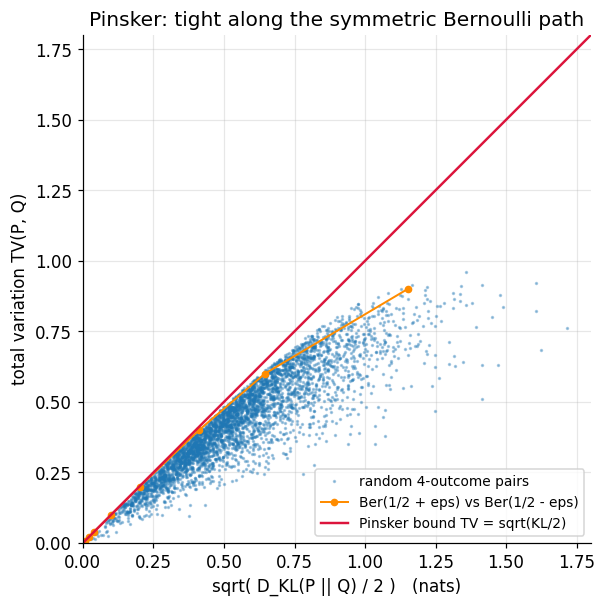

random pairs: violations of the bound   : 0 of 4000
random pairs: largest TV / sqrt(KL/2)   : 0.988961
random pairs: mean ratio, KL < 0.05     : 0.777118
random pairs: mean ratio, KL > 1.0      : 0.725171

symmetric Bernoulli family, where the constant 2 in Pinsker is optimal
     eps        TV        sqrt(KL/2)     TV / sqrt(KL/2)
    0.4500   0.900000    1.151085       0.781871
    0.3000   0.600000    0.644894       0.930385
    0.2000   0.400000    0.411655       0.971688
    0.1000   0.200000    0.201362       0.993238
    0.0500   0.100000    0.100168       0.998327
    0.0200   0.040000    0.040011       0.999733
    0.0100   0.020000    0.020001       0.999933
    0.0030   0.006000    0.006000       0.999994
    0.0010   0.002000    0.002000       0.999999


In [9]:
n_pairs = 4000
kls = np.empty(n_pairs)
tvs = np.empty(n_pairs)
for i in range(n_pairs):
    pa = rng.dirichlet(np.ones(4))
    qa = rng.dirichlet(np.ones(4))
    kls[i] = kl(pa, qa)
    tvs[i] = tv(pa, qa)
bnd = np.sqrt(0.5 * kls)

eps_grid = np.array([0.45, 0.3, 0.2, 0.1, 0.05, 0.02, 0.01, 3e-3, 1e-3])
tv_ber = 2.0 * eps_grid
bnd_ber = np.array([np.sqrt(0.5 * kl_ber(0.5 + e, 0.5 - e)) for e in eps_grid])

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.plot(bnd, tvs, ".", ms=2.5, alpha=0.35, label="random 4-outcome pairs")
ax.plot(bnd_ber, tv_ber, "o-", ms=4, lw=1.3, color="darkorange",
        label="Ber(1/2 + eps) vs Ber(1/2 - eps)")
lim = np.array([0.0, 1.05 * bnd.max()])
ax.plot(lim, lim, lw=1.6, color="crimson", label="Pinsker bound TV = sqrt(KL/2)")
ax.set_xlim(0.0, lim[1])
ax.set_ylim(0.0, lim[1])
ax.set_aspect("equal")
ax.set_xlabel("sqrt( D_KL(P || Q) / 2 )   (nats)")
ax.set_ylabel("total variation TV(P, Q)")
ax.set_title("Pinsker: tight along the symmetric Bernoulli path")
ax.legend(loc="lower right", fontsize=9)
plt.show()

ratio = tvs / bnd
print(f"random pairs: violations of the bound   : {int(np.sum(tvs > bnd))} of {n_pairs}")
print(f"random pairs: largest TV / sqrt(KL/2)   : {ratio.max():.6f}")
print(f"random pairs: mean ratio, KL < 0.05     : {ratio[kls < 0.05].mean():.6f}")
print(f"random pairs: mean ratio, KL > 1.0      : {ratio[kls > 1.0].mean():.6f}")
print("\nsymmetric Bernoulli family, where the constant 2 in Pinsker is optimal")
print("     eps        TV        sqrt(KL/2)     TV / sqrt(KL/2)")
for e, a_, b_ in zip(eps_grid, tv_ber, bnd_ber):
    print(f"  {e:8.4f}   {a_:.6f}    {b_:.6f}       {a_ / b_:.6f}")
assert np.all(tvs <= bnd + 1e-12)
assert np.all(tv_ber <= bnd_ber + 1e-12)
assert abs(tv_ber[-1] / bnd_ber[-1] - 1.0) < 1e-5

Not one of the four thousand random pairs crosses the line: the largest ratio observed is
$0.988961$ and the mean is $0.777118$ among the near pairs with $D_{\mathrm{KL}} \lt 0.05$ and
$0.725171$ among the far pairs with $D_{\mathrm{KL}} \gt 1$.

The orange path is the point of the figure. Along the symmetric Bernoulli family the ratio climbs
monotonically from $0.781871$ at $\varepsilon = 0.45$ to $0.999999$ at $\varepsilon = 10^{-3}$: the
constant $2$ inside the square root of Theorem 4.7 cannot be improved, and the bound is attained in
the limit $P \to Q$ — which is the regime it is used in, certifying that two nearly identical models
cannot be told apart.

A random pair is generically far from that path, which is why the cloud sits below the line even
when its divergence is small: tightness is a statement about a direction of approach, not about
every small perturbation.

### 7.6 The whole family on one axis

Fixing $Q = \mathrm{Ber}(0.5)$ and sweeping $P = \mathrm{Ber}(a)$ across $(0,1)$ shows all six
divergences of Definition 3.4 on one axis. The sweep also isolates *which argument* causes a
divergence to blow up, because only the first one moves.

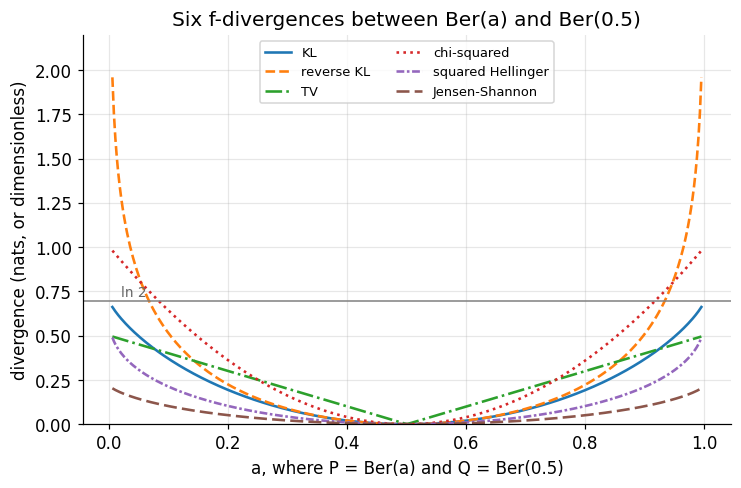

values at a = 0.9
  KL                 = 0.368064
  reverse KL         = 0.510826
  TV                 = 0.400000
  chi-squared        = 0.640000
  squared Hellinger  = 0.211146
  Jensen-Shannon     = 0.101749

ordering at a = 0.9 required by the exercises: H^2 <= KL <= chi^2 : 0.211146 <= 0.368064 <= 0.640000
JS ceiling respected: 0.101749 <= ln 2 = 0.693147

against a uniform Q, forward KL is bounded:  D(P || unif) = ln 2 - H(P)
  a =  0.005   D(P||Q) = 0.661668   ln 2 - H(P) = 0.661668   D(Q||P) = 1.958518
  a =  0.100   D(P||Q) = 0.368064   ln 2 - H(P) = 0.368064   D(Q||P) = 0.510826
  a =  0.300   D(P||Q) = 0.082283   ln 2 - H(P) = 0.082283   D(Q||P) = 0.087177
  a =  0.500   D(P||Q) = 0.000000   ln 2 - H(P) = 0.000000   D(Q||P) = 0.000000
  a =  0.900   D(P||Q) = 0.368064   ln 2 - H(P) = 0.368064   D(Q||P) = 0.510826
  a =  0.995   D(P||Q) = 0.661668   ln 2 - H(P) = 0.661668   D(Q||P) = 1.958518
  worst residual of the identity = 5.551e-17 = 0.25 * eps


In [10]:
a_grid = np.linspace(0.005, 0.995, 400)
Qb = np.array([0.5, 0.5])
curves = {"KL": [], "reverse KL": [], "TV": [], "chi-squared": [],
          "squared Hellinger": [], "Jensen-Shannon": []}
for a in a_grid:
    Pb = np.array([a, 1.0 - a])
    curves["KL"].append(kl(Pb, Qb))
    curves["reverse KL"].append(kl(Qb, Pb))
    curves["TV"].append(tv(Pb, Qb))
    curves["chi-squared"].append(chi2(Pb, Qb))
    curves["squared Hellinger"].append(hellinger2(Pb, Qb))
    curves["Jensen-Shannon"].append(js(Pb, Qb))

fig, ax = plt.subplots(figsize=(7.6, 4.6))
styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2))]
for (name, ys), st in zip(curves.items(), styles):
    ax.plot(a_grid, ys, ls=st, lw=1.7, label=name)
ax.axhline(np.log(2.0), lw=1.0, color="0.5")
ax.annotate("ln 2", (0.02, np.log(2.0) + 0.03), fontsize=9, color="0.4")
ax.set_ylim(0.0, 2.2)
ax.set_xlabel("a, where P = Ber(a) and Q = Ber(0.5)")
ax.set_ylabel("divergence (nats, or dimensionless)")
ax.set_title("Six f-divergences between Ber(a) and Ber(0.5)")
ax.legend(fontsize=8.5, ncol=2)
plt.show()

print("values at a = 0.9")
Pb = np.array([0.9, 0.1])
for name, fn in [("KL", lambda: kl(Pb, Qb)), ("reverse KL", lambda: kl(Qb, Pb)),
                 ("TV", lambda: tv(Pb, Qb)), ("chi-squared", lambda: chi2(Pb, Qb)),
                 ("squared Hellinger", lambda: hellinger2(Pb, Qb)),
                 ("Jensen-Shannon", lambda: js(Pb, Qb))]:
    print(f"  {name:18s} = {fn():.6f}")
print(f"\nordering at a = 0.9 required by the exercises: H^2 <= KL <= chi^2 : "
      f"{hellinger2(Pb, Qb):.6f} <= {kl(Pb, Qb):.6f} <= {chi2(Pb, Qb):.6f}")
assert hellinger2(Pb, Qb) <= kl(Pb, Qb) <= chi2(Pb, Qb)
print(f"JS ceiling respected: {js(Pb, Qb):.6f} <= ln 2 = {np.log(2.0):.6f}")

print("\nagainst a uniform Q, forward KL is bounded:  D(P || unif) = ln 2 - H(P)")
worst_id = 0.0
for a in (0.005, 0.1, 0.3, 0.5, 0.9, 0.995):
    Pb2 = np.array([a, 1.0 - a])
    H_b = float(-np.sum(Pb2 * np.log(Pb2)))
    worst_id = max(worst_id, abs(kl(Pb2, Qb) - (np.log(2.0) - H_b)))
    print(f"  a = {a:6.3f}   D(P||Q) = {kl(Pb2, Qb):.6f}   ln 2 - H(P) = "
          f"{np.log(2.0) - H_b:.6f}   D(Q||P) = {kl(Qb, Pb2):.6f}")
print(f"  worst residual of the identity = {worst_id:.3e} = {worst_id / EPS:.2f} * eps")
assert worst_id < 10 * EPS

Only one curve escapes to infinity, and it is the **reverse** KL. That is the lesson of the sweep:
$D_{\mathrm{KL}}$ blows up because of the *second* argument, not the first. Here the second
argument is the fixed uniform $Q$, so the forward divergence is bounded — the printed identity
$D_{\mathrm{KL}}(P \parallel \mathrm{unif}) = \ln 2 - H(P)$ holds to a quarter of a machine epsilon and
caps it at $\ln 2$. Swap the arguments and $P = \mathrm{Ber}(a)$ starves an outcome the reference
still uses, and the divergence diverges.

At $a = 0.9$ the ordering $H^2 \le D_{\mathrm{KL}} \le \chi^2$ holds, at $0.211146$, $0.368064$
and $0.640000$ — the chain the exercises prove.

Jensen-Shannon is the flattest curve of the six, and the flattening is not cosmetic: it is exactly
why a Jensen-Shannon objective gives a generator almost no gradient once its samples miss the data,
while an unbounded divergence keeps pushing.

### 7.7 Measuring the Sanov exponent

The last cell recomputes the exact probability that $n$ tosses of a fair coin produce at least
$70$ percent heads, and compares the measured exponent $-\tfrac{1}{n}\ln \mathbb{P}$ with the
predicted $D^{\star} = D_{\mathrm{KL}}(\mathrm{Ber}(0.7) \parallel \mathrm{Ber}(0.5))$ and with the
type-count bound of Theorem 4.9.

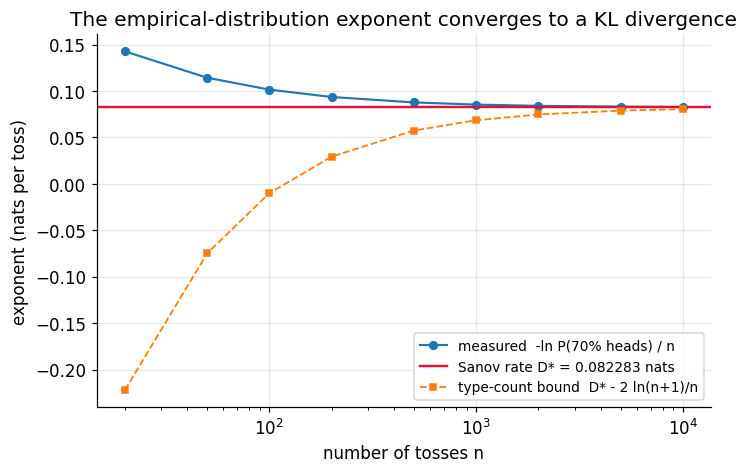

     n     log10 of exact tail    measured exponent   measured / D*
      20            -1.239          0.142660          1.7338
      50            -2.481          0.114275          1.3888
     100            -4.406          0.101455          1.2330
     200            -8.123          0.093518          1.1365
     500           -19.038          0.087671          1.0655
    1000           -37.054          0.085320          1.0369
    2000           -72.939          0.083974          1.0205
    5000          -180.342          0.083051          1.0093
   10000          -359.167          0.082701          1.0051

D* = 0.082283 nats;  measured exponent at n = 10000 is 0.082701, 0.51 percent above it


In [11]:
def log_binom_tail(n, k, prob=0.5):
    """log P(Bin(n, prob) >= k), computed stably by log-sum-exp over the summands."""
    j = np.arange(k, n + 1)
    log_terms = (special.gammaln(n + 1) - special.gammaln(j + 1) - special.gammaln(n - j + 1)
                 + j * np.log(prob) + (n - j) * np.log1p(-prob))
    return float(special.logsumexp(log_terms))


ns = np.array([20, 50, 100, 200, 500, 1000, 2000, 5000, 10000])
log_tails = np.array([log_binom_tail(n, int(np.ceil(0.7 * n))) for n in ns])
measured = -log_tails / ns
bound_exponent = D_star - 2 * np.log(ns + 1) / ns

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.semilogx(ns, measured, "o-", ms=5, lw=1.4, label="measured  -ln P(70% heads) / n")
ax.axhline(D_star, lw=1.6, color="crimson", label=f"Sanov rate D* = {D_star:.6f} nats")
ax.semilogx(ns, bound_exponent, "s--", ms=4, lw=1.2,
            label="type-count bound  D* - 2 ln(n+1)/n")
ax.set_xlabel("number of tosses n")
ax.set_ylabel("exponent (nats per toss)")
ax.set_title("The empirical-distribution exponent converges to a KL divergence")
ax.legend(fontsize=9)
plt.show()

print("     n     log10 of exact tail    measured exponent   measured / D*")
for n, lt, m in zip(ns, log_tails, measured):
    print(f"  {n:6d}        {lt / np.log(10):10.3f}          {m:.6f}          {m / D_star:.4f}")
print(f"\nD* = {D_star:.6f} nats;  measured exponent at n = 10000 is {measured[-1]:.6f}, "
      f"{100 * (measured[-1] / D_star - 1):.2f} percent above it")
assert np.all(measured >= bound_exponent - 1e-12)
assert abs(measured[-1] / D_star - 1.0) < 0.01

The measured exponent decreases monotonically towards $D^{\star} = 0.082283$ and sits $0.51$
percent above it at $n = 10^{4}$. The approach is from above and slow — the correction is of order
$\ln n / n$, exactly the polynomial prefactor of Theorem 4.9 — and the dashed curve, the bound with
that prefactor put back, tracks the measurement from below at every $n$.

The tail itself falls from $5.8 \times 10^{-2}$ at $n = 20$ to $10^{-359}$ at $n = 10^{4}$. That
range of $357$ orders of magnitude is produced by one number, $0.082283$ nats per toss.

## 8. Applications

Four settings run on the results above. In each, the object being minimized is a relative entropy
for a structural reason, and the direction of the bars is a design decision with visible
consequences.

### 8.1 Variational autoencoders and the Gaussian regularizer

A variational autoencoder maximizes a lower bound on $\ln p(x)$ whose penalty term is exactly the
divergence of Theorem 4.6 between the encoder posterior and the prior. For a diagonal Gaussian
encoder $q_\phi(z \mid x) = \mathcal{N}(\mu, \operatorname{diag}(\sigma^2))$ and prior
$\mathcal{N}(0, I)$, Theorem 4.5 splits the divergence across coordinates and Theorem 4.6 evaluates
each one:

$$
D_{\mathrm{KL}}\bigl(q_\phi(z \mid x) \parallel \mathcal{N}(0, I)\bigr)
= \frac{1}{2}\sum_{j=1}^{d}\left(\mu_j^2 + \sigma_j^2 - 1 - \ln \sigma_j^2\right).
$$

Every term is nonnegative by Theorem 4.1 and vanishes exactly at $(\mu_j, \sigma_j) = (0, 1)$,
which is the analytic signature of a collapsed latent dimension.

The direction is reverse KL: the fitted $q_\phi$ is the first argument. Theorem 4.8 therefore
predicts the observed failure mode — posteriors that are too narrow rather than too wide.

### 8.2 KL-regularized policy optimization

Reinforcement learning from human feedback maximizes
$\mathbb{E}_{y \sim \pi_\theta}[r(y)] - \beta D_{\mathrm{KL}}(\pi_\theta \parallel \pi_{\mathrm{ref}})$.

Maximizing over all distributions $\pi_\theta$ has the closed-form solution

$$
\pi^{\star}(y) \;\propto\; \pi_{\mathrm{ref}}(y)\, e^{r(y)/\beta},
$$

obtained by writing the objective as $-\beta D_{\mathrm{KL}}(\pi_\theta \parallel \pi^{\star})$ plus
a constant and applying the equality clause of Theorem 4.1. The convexity that makes this a
well-posed problem is the subject of
[optimization/01 — Problem Formulation and Convexity](../../optimization/01_problem_formulation_and_convexity/).

Two consequences follow from results above. Because the penalty is a **reverse** KL in
$\pi_\theta$, it is finite only when $\pi_\theta \ll \pi_{\mathrm{ref}}$: the tuned policy is
confined to the reference model's support, which is what prevents reward hacking into degenerate
text. And because of Theorem 4.8 the same penalty is mode-seeking, so aggressive tuning narrows the
output distribution rather than shifting it.

Trust-region methods use the same quantity as a constraint,
$D_{\mathrm{KL}}(\pi_{\mathrm{old}} \parallel \pi_{\mathrm{new}}) \le \delta$; by Section 7.3 that
constraint is locally the quadratic form $\tfrac12 \Delta\theta^{\top} \mathcal{I} \Delta\theta$,
which is why the natural gradient is the geometry-correct step.

### 8.3 Generative adversarial training and the $f$-GAN family

At the optimal discriminator $D^{\star} = p/(p+g)$, the original GAN value function equals
$2\,\mathrm{JS}(p, g) - 2\ln 2$. Definition 3.5 bounds $\mathrm{JS}$ by $\ln 2$, so the objective
saturates: when the generator's samples and the data lie on disjoint supports the objective sits at
its ceiling and its gradient in the generator parameters vanishes.

Section 7.6 shows that flattening directly. It is the reason non-saturating losses, instance noise
and Wasserstein objectives were introduced, and the reason a Jensen-Shannon table entry with the
wrong normalization (Example 6.9) misstates where the ceiling is.

More generally, every $f$-divergence has a discriminator-shaped variational form, so choosing $f$
chooses the loss, the output activation and the failure mode of the resulting game.

### 8.4 Statistics and physics

**Testing.** By Theorem 4.5 the divergence of $n$ i.i.d. observations is $n D_{\mathrm{KL}}$, and
by Theorem 4.9 an atypical empirical distribution is exponentially rare at rate exactly its
relative entropy from the truth. That is why the optimal test's error exponent, and hence the
sample complexity of distinguishing two models, is a KL divergence rather than a distance.

**Model selection.** Ranking fitted models by expected out-of-sample log-likelihood is ranking them
by $D_{\mathrm{KL}}(p \parallel q_{\hat{\theta}})$, since the entropy term does not depend on the
model. The Akaike criterion is a bias correction for the fact that the in-sample log-likelihood is
optimistic.

**Thermodynamics.** For a system with energies $E(x)$ at inverse temperature $\beta = 1/(k_B T)$,
the Gibbs state is $\pi(x) \propto e^{-\beta E(x)}$ and the nonequilibrium free energy of any state
$p$ satisfies

$$
F(p) - F(\pi) = k_B T \, D_{\mathrm{KL}}(p \parallel \pi) \;\ge\; 0,
$$

by Theorem 4.1. Relaxation to equilibrium is descent in relative entropy, and Landauer's bound —
erasing one bit costs at least $k_B T \ln 2$ of heat — is the same statement applied to a
two-state system. Both are computed in the exercises.

**Coding.** The excess description length from using a $Q$-code on $P$-data is
$H_{\times}(p, q) - H(p) = D_{\mathrm{KL}}(P \parallel Q)$, the identity checked in Section 7.1;
it is derived in
[Module 03 — Cross-Entropy and Loss Functions](../03_cross_entropy_and_loss_functions/first_principles.ipynb).

## 9. Key Takeaways

- **Every $f$-divergence is nonnegative**, and vanishes only at $P = Q$ when the generator is
  strictly convex at $1$ (Theorem 4.1). The proof is one supporting hyperplane plus the fact that
  both distributions are normalized — no property of the logarithm is used.

- **Merging cells cannot increase relative entropy** and costs nothing exactly when the merged
  cells had equal likelihood ratios (Theorem 4.2). Example 6.2 measures a gap of $0.141695$ nats
  on two cells with ratios $5$ and $1.5$.

- **$D_f$ is jointly convex in the pair $(P, Q)$** because the perspective function $vf(u/v)$ is
  (Theorem 4.3). Everything structural in this module is a corollary of that one convexity.

- **No processing can increase any $f$-divergence** (Theorem 4.4). For a strictly convex generator,
  equality holds exactly when the output preserves the likelihood ratio, that is when it is a
  sufficient statistic for the pair. Strict convexity is necessary: Example 6.3 exhibits a channel
  that preserves total variation exactly while $D_{\mathrm{KL}}$ drops.

- **Relative entropy is additive over a factorization**, so $n$ i.i.d. observations carry
  $n D_{\mathrm{KL}}$ (Theorem 4.5), and it has the closed Gaussian form of Theorem 4.6 that every
  variational autoencoder evaluates in its forward pass.

- **Small KL forces small total variation**, $\mathrm{TV} \le \sqrt{D_{\mathrm{KL}}/2}$
  (Theorem 4.7), and there is no converse: Section 7.4 drives $\mathrm{TV}$ to $10^{-4}$ with
  $D_{\mathrm{KL}} = +\infty$.

- **The two directions optimize different things** (Theorem 4.8). Forward KL is a moment match and
  is unique; reverse KL is a mode selection whose objective has one minimum per mode, each capped
  at $\ln 2$, separated by a barrier that grows with the mode separation.

- **Locally, relative entropy is a quadratic form** with the Fisher information as its matrix:
  Section 7.3 measures order $1.9853$ against the predicted $2$. Globally it is not a metric and
  not symmetric.

- **A rare empirical distribution is exponentially rare at rate $D_{\mathrm{KL}}$** (Theorem 4.9).
  Seeing $70$ percent heads in $2000$ fair tosses has probability $10^{-73}$, and the exponent is
  $0.082283$ nats per toss.

- **Generators are defined up to $c(t-1)$ and up to positive scale** (Proposition 4.10), so a
  generator table without a stated normalization is ambiguous by a factor: the usual Jensen-Shannon
  generator produces $2\,\mathrm{JS}$, with ceiling $2\ln 2$.

## 10. References

**Textbooks.**

- Cover, T. M. and Thomas, J. A. *Elements of Information Theory*, 2nd ed., Wiley, 2006 — relative
  entropy and the information inequality (section 2.6, Theorem 2.6.3), the log-sum inequality and
  convexity (section 2.7, Theorem 2.7.1), the data-processing inequality (section 2.8), the method
  of types (section 11.1, Theorems 11.1.1-11.1.4), Sanov's theorem (section 11.4, Theorem 11.4.1,
  p. 362), Chernoff-Stein (section 11.8, Theorem 11.8.3), and Pinsker's inequality (Lemma 11.6.1).
- MacKay, D. J. C. *Information Theory, Inference, and Learning Algorithms*, Cambridge University
  Press, 2003 — chapter 2 (relative entropy and Gibbs' inequality), chapter 33 (variational free
  energy and the reverse-KL objective).
- Polyanskiy, Y. and Wu, Y. *Information Theory: From Coding to Learning*, Cambridge University
  Press, 2024 — chapter 7 (the $f$-divergence toolbox, the joint range, and the inequality chains
  between TV, Hellinger, $\chi^2$ and KL).
- Csiszar, I. and Korner, J. *Information Theory: Coding Theorems for Discrete Memoryless Systems*,
  2nd ed., Cambridge University Press, 2011 — chapter 1, Lemma 1.2 (log-sum) and the type-counting
  lemmas used in Proof 5.9.
- Amari, S. *Information Geometry and Its Applications*, Springer, 2016 — chapters 1 and 3, the
  Fisher metric as the local quadratic form of relative entropy measured in Section 7.3.
- Boyd, S. and Vandenberghe, L. *Convex Optimization*, Cambridge University Press, 2004 —
  section 3.2.6 (the perspective function used in Proof 5.3) and section 3.1.5 (Jensen).

**Papers.**

- Kullback, S. and Leibler, R. A. "On information and sufficiency", *Annals of Mathematical
  Statistics* **22**(1) (1951), 79-86 — the original definition and the sufficiency invariance
  proved here as the equality case of Theorem 4.4.
- Csiszar, I. "Information-type measures of difference of probability distributions and indirect
  observations", *Studia Scientiarum Mathematicarum Hungarica* **2** (1967), 299-318 — the
  $f$-divergence framework of Definition 3.3.
- Goodfellow, I. et al. "Generative adversarial nets", *NeurIPS* (2014) — the Jensen-Shannon
  reading of the discriminator objective, section 4.1.
- Nowozin, S., Cseke, B. and Tomioka, R. "f-GAN: training generative neural samplers using
  variational divergence minimization", *NeurIPS* (2016) — Table 1, whose Jensen-Shannon row is the
  unhalved generator of Example 6.9.
- Kingma, D. P. and Welling, M. "Auto-encoding variational Bayes", *ICLR* (2014), Appendix B — the
  diagonal Gaussian form of section 8.1.
- Schulman, J. et al. "Trust region policy optimization", *ICML* (2015) — the KL-constrained update
  of section 8.2.
- Donsker, M. D. and Varadhan, S. R. S. "Asymptotic evaluation of certain Markov process
  expectations for large time", *Communications on Pure and Applied Mathematics* **28** (1975),
  1-47 — the variational formula proved in exercise L3.1.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions, including $H_{\times}$ for cross-entropy: [the notation register](../../docs/notation.md).
- Entropy and the tangent-line bound reused in Proof 5.1:
  [Module 01 — Self-Information and Entropy](../01_self_information_and_entropy/first_principles.ipynb).
- Joint and conditional entropy, used in the chain rule of Theorem 4.5:
  [Module 02 — Joint and Conditional Entropy](../02_joint_and_conditional_entropy/first_principles.ipynb).
- Cross-entropy and the identity $H_{\times}(p,q) = H(p) + D_{\mathrm{KL}}(p \parallel q)$:
  [Module 03 — Cross-Entropy and Loss Functions](../03_cross_entropy_and_loss_functions/first_principles.ipynb).
- Convexity, Jensen and the perspective function:
  [optimization/01 — Problem Formulation and Convexity](../../optimization/01_problem_formulation_and_convexity/).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).